# Projet de Machine Learning
## Gym Members Exercise Dataset

### EHRHART Elsa, SLISSE Paul, STAUB Guillaume, HOSSEINI Arman

### 0. Librairies

In [93]:
library(lubridate)
library(dplyr)
library(tidyr)
library(ggplot2)
library(GGally)
library(corrplot)
library("FactoMineR")
library("factoextra")
library(reshape2)
library(MASS)
library(effectsize)
library(gplots)
library(graphics)
library(ggpubr)
library(NMF)
library(scales)

NMF - BioConductor layer [OK] | Shared memory capabilities [NO: windows] | Cores 2/2



### I.Exploration et nettoyage du dataset
### Data loading  
In the following project we will analyse a dataset with several data about some songs listened on Spotify.  
For each song we have the following variables :
- track_id
- track_name
- track_artist
- track_popularity : a grade between 0 and 100
- track_album_id : the id of the album of the track
- track_album_name
- track_album_release_date
- playlist_name
- playlist_genre
- danceability : float between 0 and 1 to quantify if the track is danceable, based on some criterion like tempo, rhythm stability, beat strength, and overall regularity
-  energy : float between 0 and 1 representing a perceptual measure of intensity and activity
-  key : estimated key of the track, 0=C, 1=C#, 2=D ... -1=no key detected
-  loudness : overall loudness in average of a track in decibels (dB), represents the quality of a sound
-  mode : modality of a track : major = 1, minor = 0
-  speechiness : float between 0 and 1 indicating the presence of spoken word in a track >2/3 : almost only spoken words, 1/3< <2/3 : contains both music and speech, <1/3 : music and non-speech-like tracks
-  acousticness : float between 0 and 1 describing if the song is accoustic
-  instrumentalness : float between 0 and 1 representing if the track is more vocal : close to 0 or intrumental : close to 1
-  liveness : float between 0 and 1 detecting the presence or not of an audience. Above 0.8 the track is probably a live
-  valence :  a float between 0 and 1 mesuring the positiveness of a song (close to 1)
-  tempo : tempo in beats per minute (BPM)
-  duration_ms

In [1]:
path <- "spotify_songs.csv"
song <- read.csv(path, header = TRUE)
# Premières lignes du jeu de données
head(song)
# Vérification du contenu
summary(song)

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,⋯,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxury Remix,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury Remix],2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,6,-2.634,1,0.0583,0.1020,0.00e+00,0.0653,0.518,122.036,194754
2,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,11,-4.969,1,0.0373,0.0724,4.21e-03,0.3570,0.693,99.972,162600
3,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,1,-3.432,0,0.0742,0.0794,2.33e-05,0.1100,0.613,124.008,176616
4,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,7,-3.778,1,0.1020,0.0287,9.43e-06,0.2040,0.277,121.956,169093
5,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,1,-4.672,1,0.0359,0.0803,0.00e+00,0.0833,0.725,123.976,189052
6,7fvUMiyapMsRRxr07cU8Ef,Beautiful People (feat. Khalid) - Jack Wins Remix,Ed Sheeran,67,2yiy9cd2QktrNvWC2EUi0k,Beautiful People (feat. Khalid) [Jack Wins Remix],2019-07-11,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,8,-5.385,1,0.1270,0.0799,0.00e+00,0.1430,0.585,124.982,163049


   track_id          track_name        track_artist       track_popularity
 Length:32833       Length:32833       Length:32833       Min.   :  0.00  
 Class :character   Class :character   Class :character   1st Qu.: 24.00  
 Mode  :character   Mode  :character   Mode  :character   Median : 45.00  
                                                          Mean   : 42.48  
                                                          3rd Qu.: 62.00  
                                                          Max.   :100.00  
 track_album_id     track_album_name   track_album_release_date
 Length:32833       Length:32833       Length:32833            
 Class :character   Class :character   Class :character        
 Mode  :character   Mode  :character   Mode  :character        
                                                               
                                                               
                                                               
 playlist_name      playlis

On va décomposer la variable de date en jour mois année puis uniquement récupérer le mois et l'année.

In [2]:
song <- data.frame(song)
#summary(song)
song$month <- format(as.Date(song$track_album_release_date, "%Y-%m-%d"), "%m")
#summary(song)
song$year <- format(as.Date(song$track_album_release_date, "%Y-%m-%d"), "%Y")
song<-subset(song, select=-track_album_release_date)


Attachement du package : 'lubridate'


Les objets suivants sont masqués depuis 'package:base':

    date, intersect, setdiff, union



Attachement du package : 'dplyr'


Les objets suivants sont masqués depuis 'package:stats':

    filter, lag


Les objets suivants sont masqués depuis 'package:base':

    intersect, setdiff, setequal, union




On va tout d'abord regarder si on a des duplicatas dans notre dataset en utilisant le track_id.

In [3]:
sum(duplicated(song$track_id))
#song<-song[!duplicated(song$track_id),]

[1] 4477

On voit qu'on a beaucoup de duplicatas. En cherchant dans le dataset, on a découvert que ces duplicatas sont enfait dans différentes playlists qui n'ont pas le même genre. On en déduit que l'extraction des données a été faites via les playlists et c'est donc pour cela qu'on a des duplicatas. Nous allons garder qu'une seule occurence de chaque musique, pour choisir laquelle, nous allons garder une dont le genre (puis le sous-genre) est le mode des différents genres de la musique (différents genres des différentes occurences de la musique). Exemple: Dancing Queen apparait 3 fois, 2 fois avec pop et une fois avec latin, on va garder une occurence de pop.

In [4]:

song <- song %>%
  # 1. Compter combien de fois chaque genre apparaît par track
  group_by(track_name, playlist_genre) %>%
  add_count(name = "genre_count") %>%
  
  # 2. Garder le genre le plus fréquent pour chaque track
  group_by(track_name) %>%
  arrange(desc(genre_count), .by_group = TRUE) %>%
  slice(1) %>%
  ungroup() %>%
  select(-genre_count) %>%
  
  # 3. Recompter pour le sous-genre uniquement parmi les lignes conservées
  group_by(track_name, playlist_subgenre) %>%
  add_count(name = "subgenre_count") %>%
  
  # 4. Garder le sous-genre le plus fréquent pour chaque track
  group_by(track_name) %>%
  arrange(desc(subgenre_count), .by_group = TRUE) %>%
  slice(1) %>%
  ungroup() %>%
  select(-subgenre_count)
sum(duplicated(song$track_id))

[1] 0

>Nous allons maintenant supprimer les variables inutiles à l'analyse comme le track_id (un identifiant différent par musique) qui ne sera d'aucune utilité pour notre analyse car l'information est déjà contenue dans la variable track_name que nous n'utiliserons que pour labelliser.
De même, on va supprimer track_album_id,playlist_id.
>
>On va également modifier la variable de durée en la passant en secondes au lieu de millisecondes pour avoir des valeurs plus parlantes.

In [5]:
song<-subset(song,select=-track_id)
song<-subset(song,select=-track_album_id)
song<-subset(song,select=-playlist_id)
song<-subset(song, select=-track_name)

colnames(song)[which(colnames(song)=="duration_ms")]<-"duration_s"
song[,"duration_s"]<-song[,"duration_s"]/1000

head(song)

track_artist,track_popularity,track_album_name,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s,month,year
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
Iceberg Black,18,WAR,Rap Party 24/7 Radio / Gangsta Rap,rap,gangster rap,0.914,0.408,10,-6.712,0,0.1410,2.68e-02,0.001790,0.116,0.0944,140.026,150.909,09,2018
The Snake Corps,34,Smother Earth,"Maxi Pop GOLD (New Wave, Electropop, Synth Pop...)",pop,electropop,0.516,0.580,9,-13.288,0,0.0295,2.43e-06,0.857000,0.110,0.2350,135.903,238.227,01,1990
Big Tymers,48,I Got That Work,Hip-Hop Drive,rap,hip hop,0.552,0.842,8,-4.961,1,0.2850,1.76e-02,0.003270,0.258,0.5610,89.017,281.960,01,2000
XLII,26,#NAKAMA,Girl On Fire,r&b,hip pop,0.797,0.970,3,-3.204,1,0.0545,3.85e-01,0.000157,0.318,0.5680,108.041,192.094,12,2019
Paty Cantú,50,#Natural,latin hip hop,latin,latin hip hop,0.800,0.836,0,-3.535,0,0.0568,1.14e-01,0.000000,0.134,0.8160,97.023,227.013,10,2017
ARMAN,41,#Summerlovin,Tropical House 🏝 2020 Hits,latin,tropical,0.819,0.620,9,-4.711,1,0.0332,4.14e-01,0.000273,0.283,0.6950,110.005,204.562,06,2019


>On modifie certaines variables qualitatives qui nous serons utiles pour l'analyse en facteurs. D'autres comme track_name sont laissées telles quelles et seront utilisées pour la visualisation (labellisation).

In [6]:
song$playlist_genre<-as.factor(song$playlist_genre)
song$playlist_subgenre<-as.factor(song$playlist_subgenre)
song$mode<-as.factor(song$mode)
song$track_artist<-as.factor(song$track_artist)
song$track_album_name<-as.factor(song$track_album_name)
song$playlist_name<-as.factor(song$playlist_name)
summary(song)

                    track_artist   track_popularity
 Queen                    :  111   Min.   : 0.0    
 Martin Garrix            :   69   1st Qu.:23.0    
 David Guetta             :   58   Median :43.0    
 Dimitri Vegas & Like Mike:   56   Mean   :39.7    
 Don Omar                 :   54   3rd Qu.:58.0    
 (Other)                  :23101   Max.   :98.0    
 NA's                     :    1                   
                    track_album_name            playlist_name   playlist_genre
 Greatest Hits              :   94   Indie Poptimism   :  225   edm  :4031    
 Rock & Rios (Remastered)   :   29   Permanent Wave    :  181   latin:3531    
 Ultimate Freestyle Mega Mix:   28   Hard Rock Workout :  160   pop  :4153    
 Asian Dreamer              :   18   Southern Hip Hop  :  150   r&b  :3541    
 Gold                       :   18   Urban Contemporary:  142   rap  :4751    
 (Other)                    :23262   post teen pop     :  130   rock :3443    
 NA's                       :  

In [7]:
colSums(is.na(song))

track_artist  track_popularity  track_album_name     playlist_name 
                1                 0                 1                 0 
   playlist_genre playlist_subgenre      danceability            energy 
                0                 0                 0                 0 
              key          loudness              mode       speechiness 
                0                 0                 0                 0 
     acousticness  instrumentalness          liveness           valence 
                0                 0                 0                 0 
            tempo        duration_s             month              year 
                0                 0              1367              1367

On voit qu'il y a beaucoup de N.A. pour les variables mois et année, les N.A. pour les autres variables sont négligeables. D'ailleurs, pour ces variables (nom de l'artiste, nom de l'album), ça n'a pas vraiment de sens d'attribuer la variable à son mode, on va donc supprimer ces individus.

In [8]:
song<-song %>% drop_na(track_artist)

In [9]:
colSums(is.na(song))

track_artist  track_popularity  track_album_name     playlist_name 
                0                 0                 0                 0 
   playlist_genre playlist_subgenre      danceability            energy 
                0                 0                 0                 0 
              key          loudness              mode       speechiness 
                0                 0                 0                 0 
     acousticness  instrumentalness          liveness           valence 
                0                 0                 0                 0 
            tempo        duration_s             month              year 
                0                 0              1367              1367

On voit qu'on a bien supprimé tous les individus sans track_artist et track_album_name.

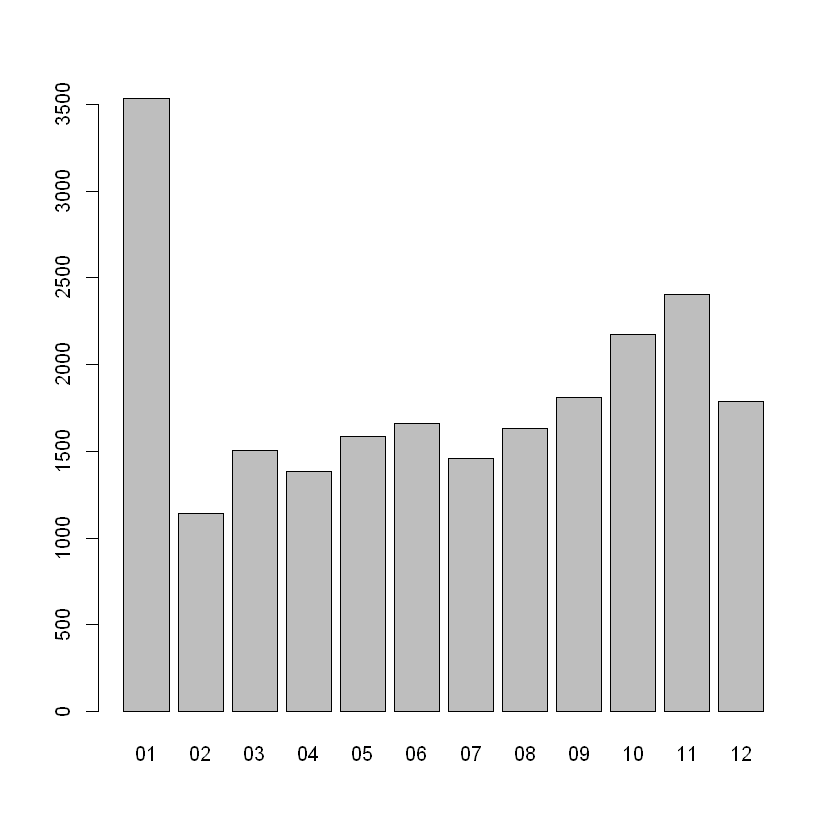

In [10]:
barplot(table(song$month))
barplot(table(song$year))

En faisant l'histogramme des entrées en fonction du mois, on voit que le mois de janvier semble sur-représenté par rapport aux autres, on décide donc d'attribuer le mois de janvier à tous les N.A. .

In [11]:
#install.packages('moder')
library(moder)
mode <- mode_first(song$month, na.rm = TRUE)
song[which(is.na(song$month), arr.ind = TRUE),]$month = mode
mode <- mode_first(song$year, na.rm = TRUE)
song$year[which(is.na(song$year), arr.ind = TRUE)] = mode

On voit que la majorité des musique sont sorties dans les années 2010, on va donc attribuer le mode pour les données manquantes.

Autre solution, supprimer tous les individus dont le mois et l'année de sortie ne sont pas définis.

In [13]:
song<-song %>% drop_na(year)
colSums(is.na(song))

track_artist  track_popularity  track_album_name     playlist_name 
                0                 0                 0                 0 
   playlist_genre playlist_subgenre      danceability            energy 
                0                 0                 0                 0 
              key          loudness              mode       speechiness 
                0                 0                 0                 0 
     acousticness  instrumentalness          liveness           valence 
                0                 0                 0                 0 
            tempo        duration_s             month              year 
                0                 0                 0                 0

On va créer une variable period qui représente la décennie de sortie de la musique.

In [15]:
song <- song %>%
  mutate(
    period = case_when(
      is.na(year)              ~ "2010s",
      year > 2010              ~ "2010s",
      year > 2000              ~ "2000s",
      year > 1990              ~ "1990s",
      year > 1980              ~ "1980s",
      year > 1970              ~ "1970s",
      year > 1960              ~ "1960s",
      TRUE                     ~ "1950s"
    ))

song$month<-as.factor(song$month)
song$year<-as.factor(song$year)
song$period <- as.factor(song$period)

In [26]:
histo_genre <- ggplot(song,aes(x=playlist_genre))+
  geom_histogram(stat="count")+
  labs(title = "Distribution des genres des musiques")

histo_year <- ggplot(song,aes(x=year))+
    geom_histogram(stat="count")+
    labs(title = "Distribution des années de sortie des musiques")+
    scale_x_discrete(breaks = levels(factor(song$year))[seq(1, length(levels(factor(song$year))), by = 10)])

histo_month <- ggplot(song,aes(x=month))+
    geom_histogram(stat="count",fill='blue')+
    labs(title = "Distribution des mois de sortie des musiques")

histo_popularity <- ggplot(song,aes(x=track_popularity))+
    geom_histogram(stat="count")+
    labs(title = "Distribution des popularités des musiques")

histo_danceability <- ggplot(song,aes(x=danceability))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la danceabilité des musiques")

histo_energy <- ggplot(song,aes(x=energy))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de l'energie des musiques")

histo_key <- ggplot(song,aes(x=key))+
    geom_histogram(bins=50,stat='count')+
    labs(title = "Distribution de la clé des musiques")

histo_loudness <- ggplot(song,aes(x=loudness))+
    geom_histogram(bins=50)+
  labs(title = "Distribution de la force sonore des musiques")

histo_mode  <- ggplot(song,aes(x=mode))+
    geom_histogram(bins=50,stat='count')+
    labs(title = "Distribution de du mode des musiques")

histo_speechiness <- ggplot(song,aes(x=speechiness))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la vocabilité des musiques")

histo_instrumentalness <- ggplot(song,aes(x=instrumentalness))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de l'intrumentabilité des musiques")

histo_liveness <- ggplot(song,aes(x=liveness))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la liveness des musiques")

histo_valence <- ggplot(song,aes(x=valence))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la valence des musiques")

histo_tempo <- ggplot(song,aes(x=tempo))+
    geom_histogram(bins=50)+
    labs(title = "Distribution du tempo des musiques")

histo_duration_s <- ggplot(song,aes(x=duration_s))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la durée des musiques")

Warning message in geom_histogram(stat = "count"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"
Warning message in geom_histogram(stat = "count"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"
Warning message in geom_histogram(stat = "count", fill = "blue"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"
Warning message in geom_histogram(stat = "count"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"
Warning message in geom_histogram(bins = 50, stat = "count"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"
Warning message in geom_histogram(bins = 50, stat = "count"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"


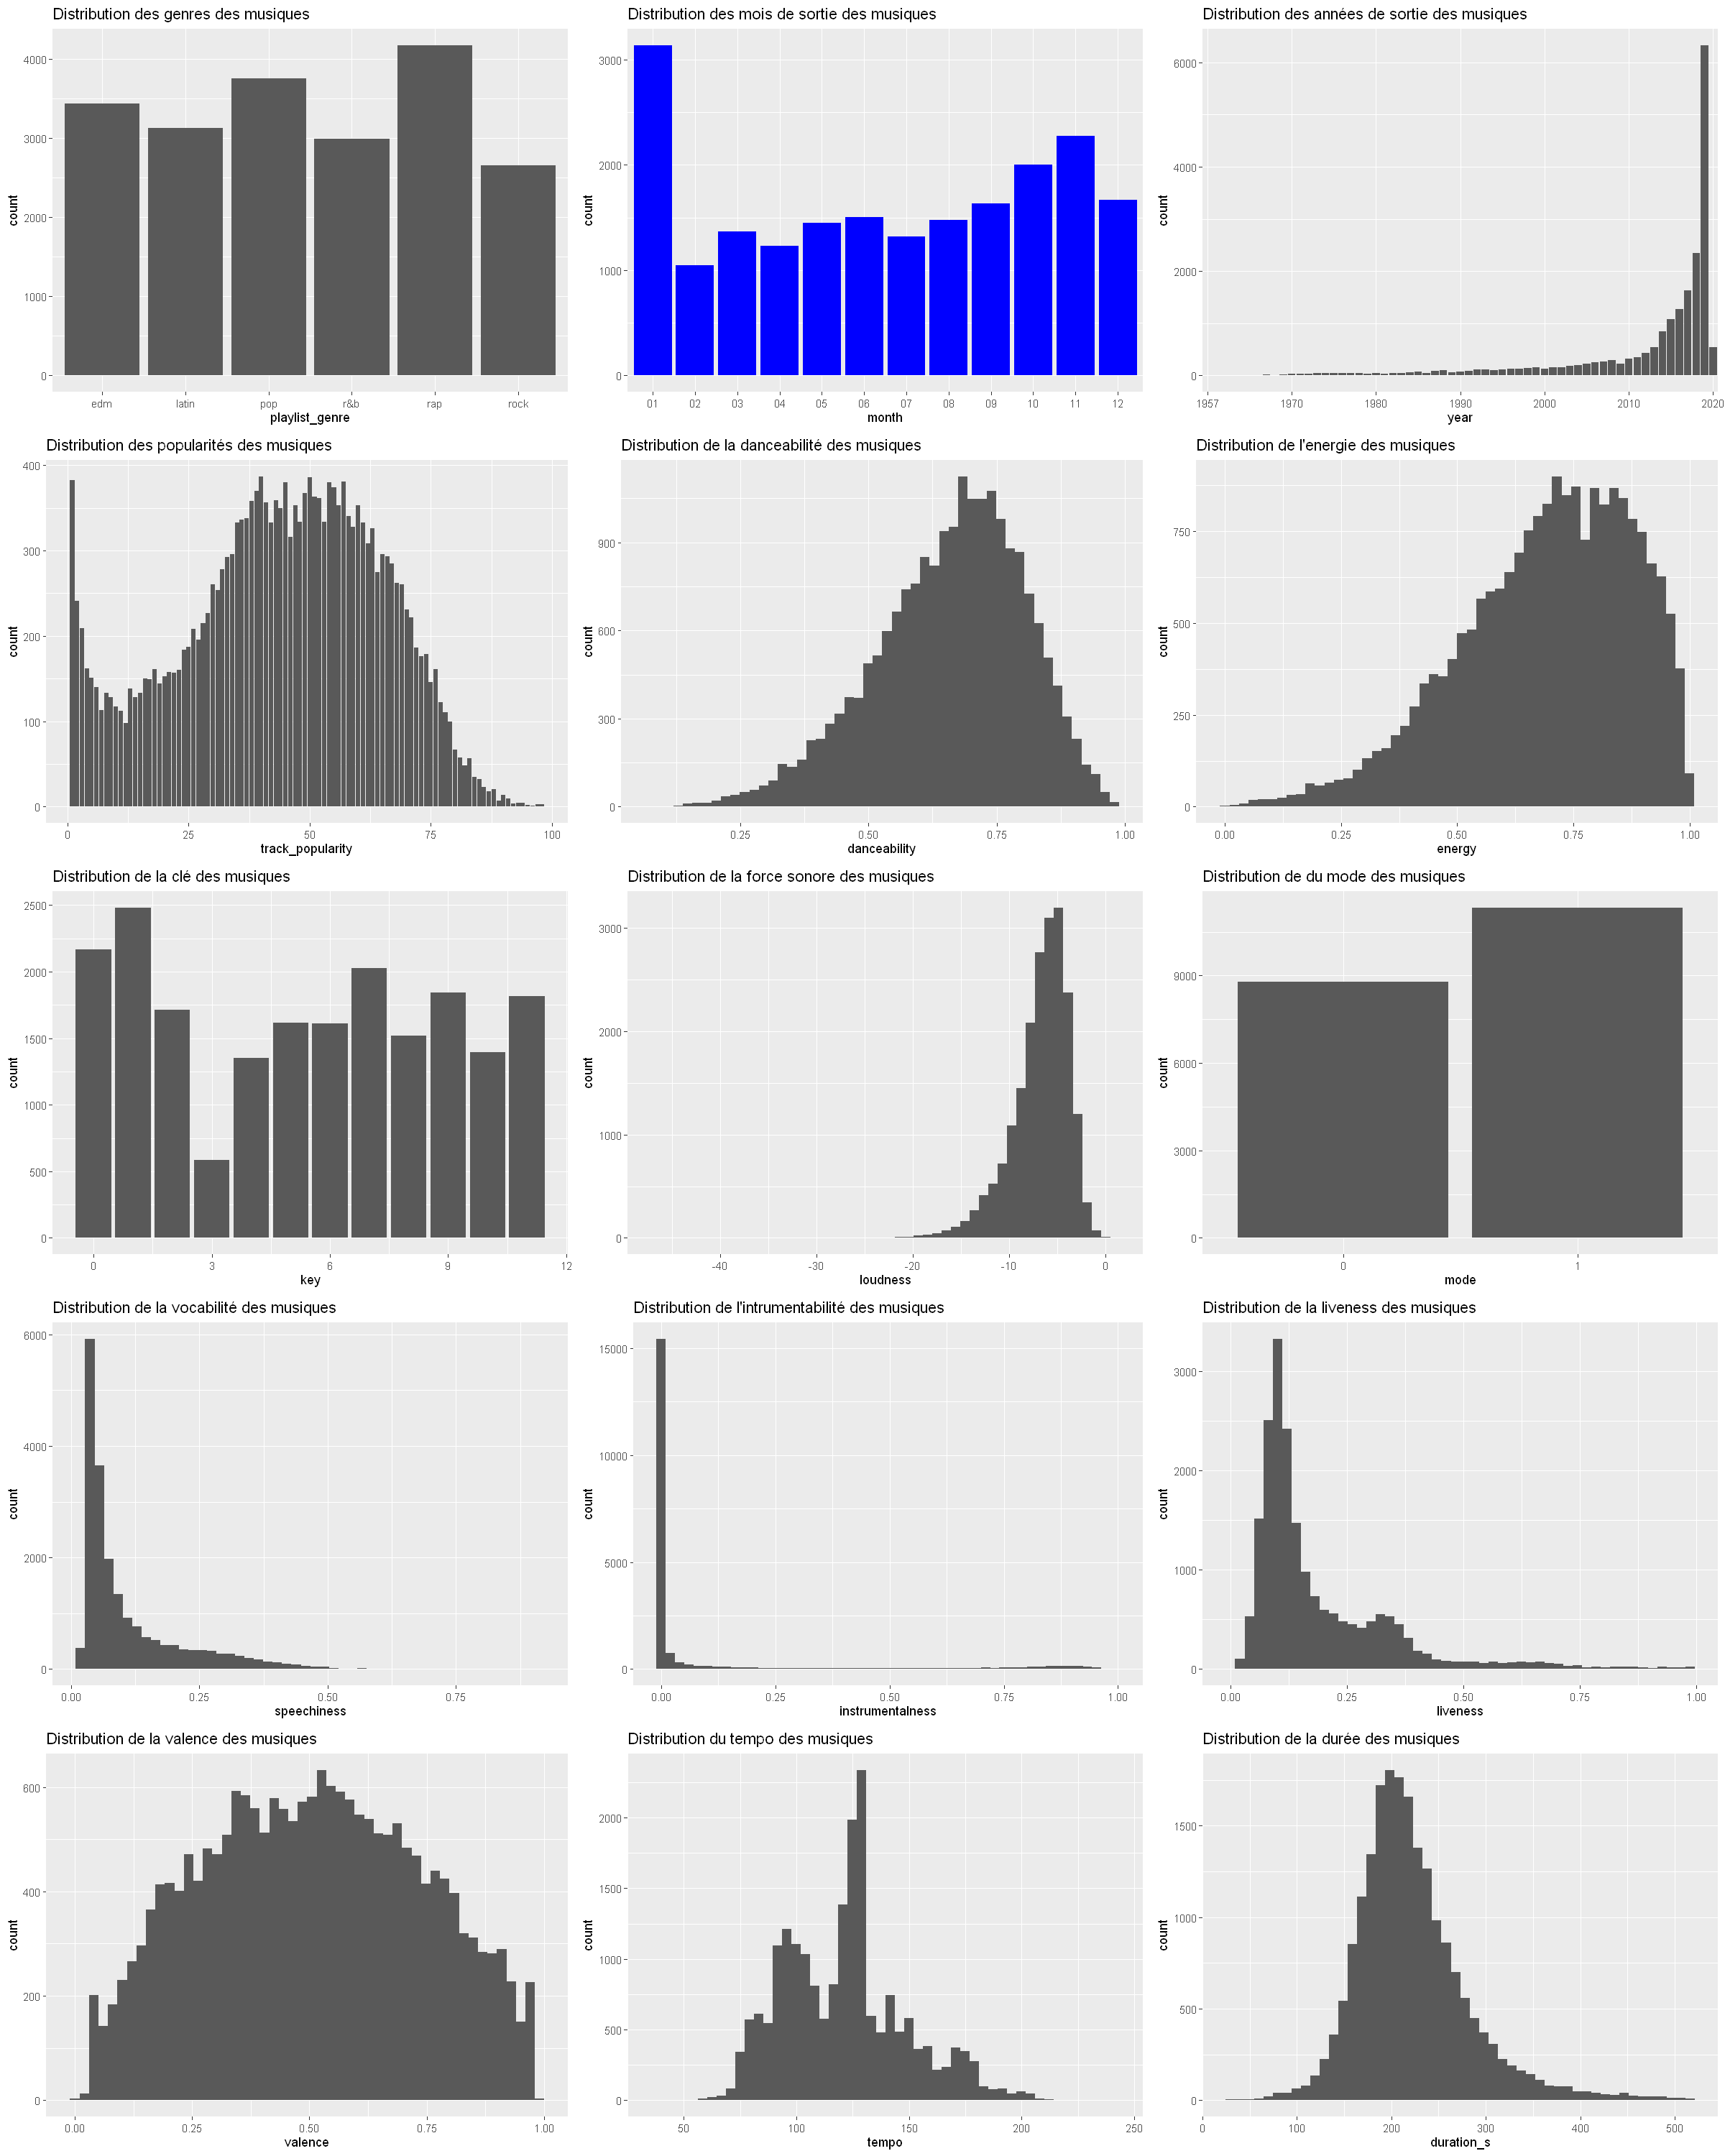

In [27]:
library("gridExtra")
options(repr.plot.width=20, repr.plot.height=25)
grid.arrange(histo_genre,histo_month,histo_year, histo_popularity,histo_danceability,histo_energy,histo_key,histo_loudness,histo_mode,histo_speechiness, histo_instrumentalness, histo_liveness,histo_valence,histo_tempo,histo_duration_s, ncol=3)

On observe qu'on a beaucoup de musique avec une très faible popularité. Afin de ne pas biaiser notre analyse, on va supprimer toutes les musiques de popularité 0, que personne n'écoute et qui ne vont donc pas être très représentatives pour nos analyses.

In [34]:
length(which(song$track_popularity==0))
song <- song[song$track_popularity != 0, ]

[1] 0

[1] 0

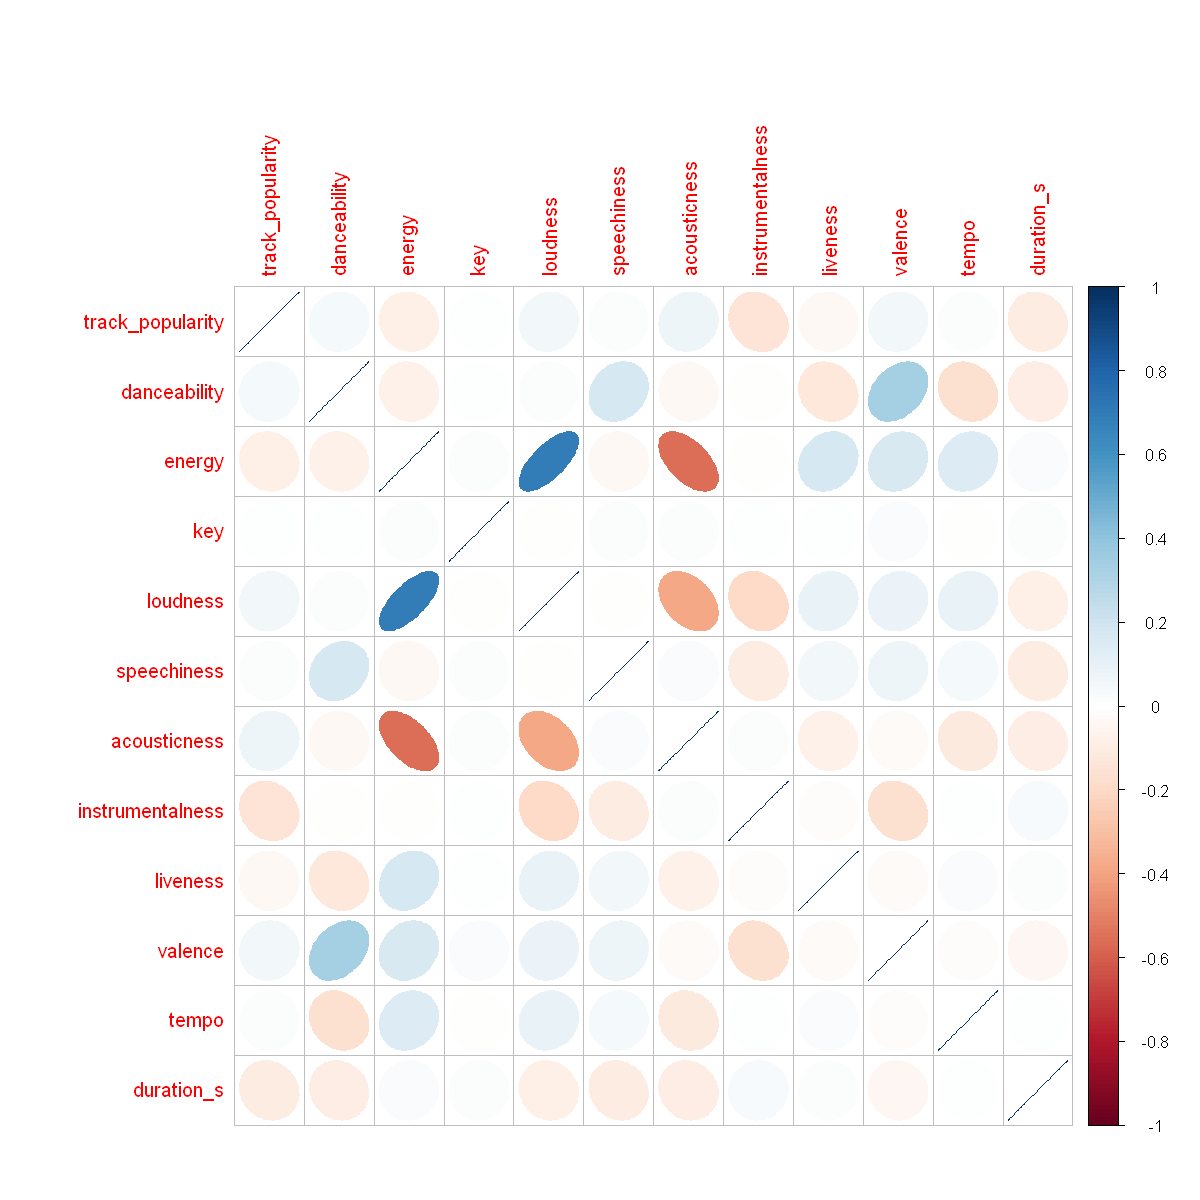

In [25]:
song_num <- song[,c(2,7:10,12:18)]
options(repr.plot.width=10, repr.plot.height=10)
corrplot(cor(song_num), method = "ellipse")
#ggpairs(song, columns = c(2, 5, 7, 8, 9, 10, 11, 12,13,14,15,16,17,18,19), columnLabels = c("track_popularity", "playlist_genre", "danceability", "energy", "key", "loudness", "mode", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo", "duration_s", "month"))

Energy and loudness are strongly positively correlated (understandable).
Energy and acousticness are negatively correlated. Loudness and acousticness are mildly negatively correlated. It is understandable because when a song gets louder, it often becomes harder to distinguish the different instruments and sounds.
Danceability and valence are mildly positively correlated. Thus a song that is easier to dance to is one that is more likely to impulse a positive feeling to its listeners.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


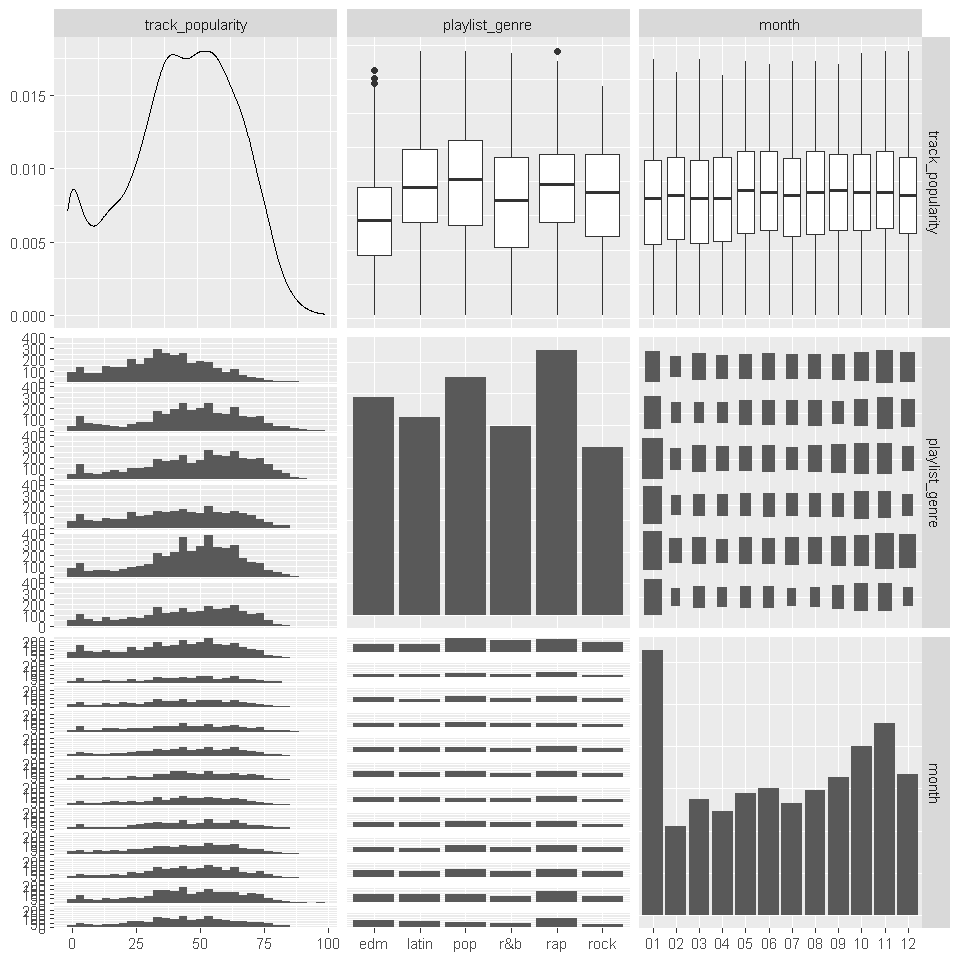

In [29]:
options(repr.plot.width=8,repr.plot.height=8)
ggpairs(song,columns=c(2, 5, 19), cardinality_threshold = 15, progress = FALSE)
#ggpairs(song,columns=c(2, 9:12), cardinality_threshold = 65, progress = FALSE)

#ggpairs(song,columns=c(2, 13:16), cardinality_threshold = 65, progress = FALSE)

We see that pop is the most popular genre in average, but the difference is slight. EDM is the least popular genre.
There does not seem to be a clear relationship between month and track popularity.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


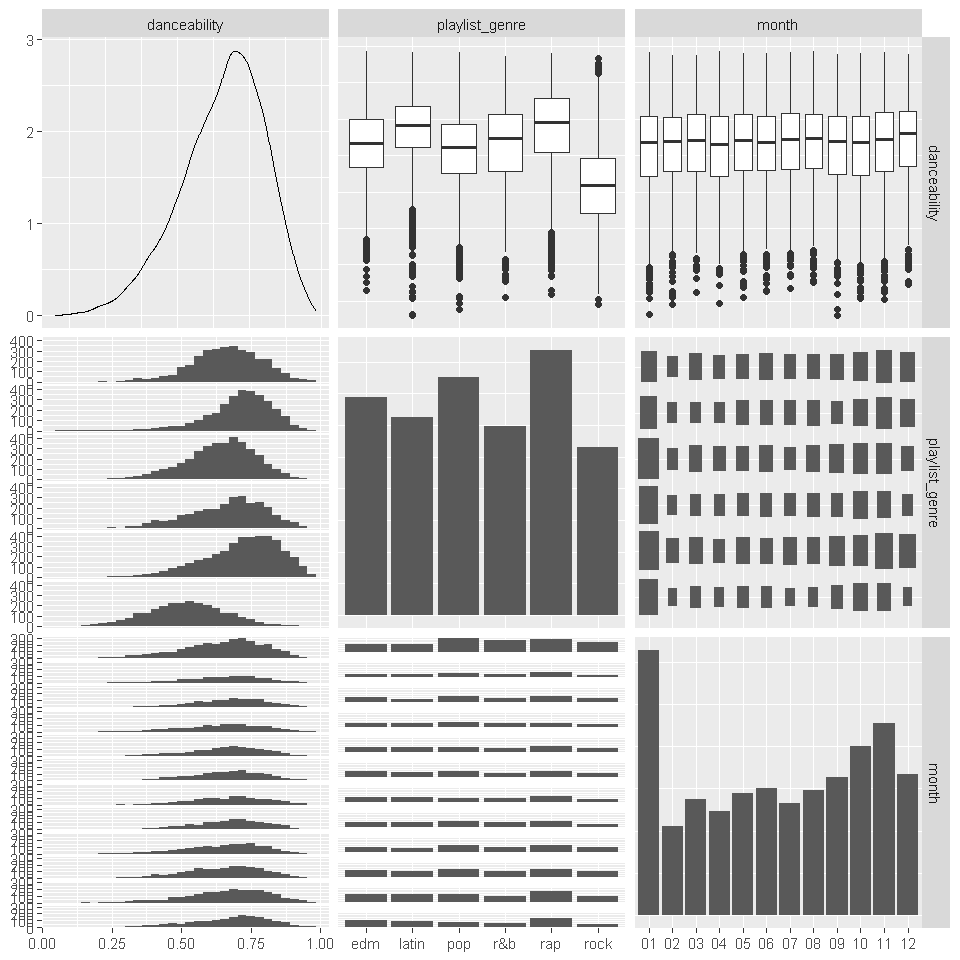

In [30]:
ggpairs(song,columns=c(7, 5, 19), cardinality_threshold = 15, progress = FALSE)

Latin and rap are the most danceable genres, rock has the worst 

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


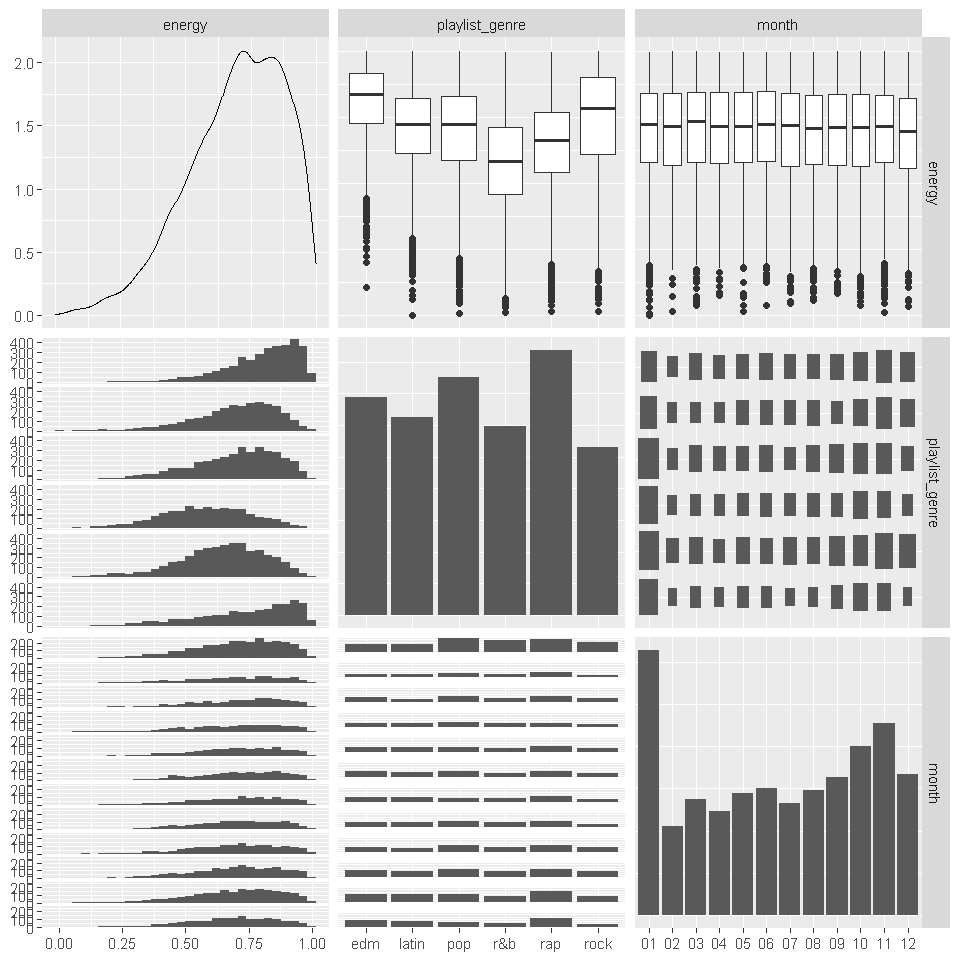

In [31]:
ggpairs(song,columns=c(8, 5, 19), cardinality_threshold = 15, progress = FALSE)

EDM is the genre with the most energy, r&b has the least energy.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


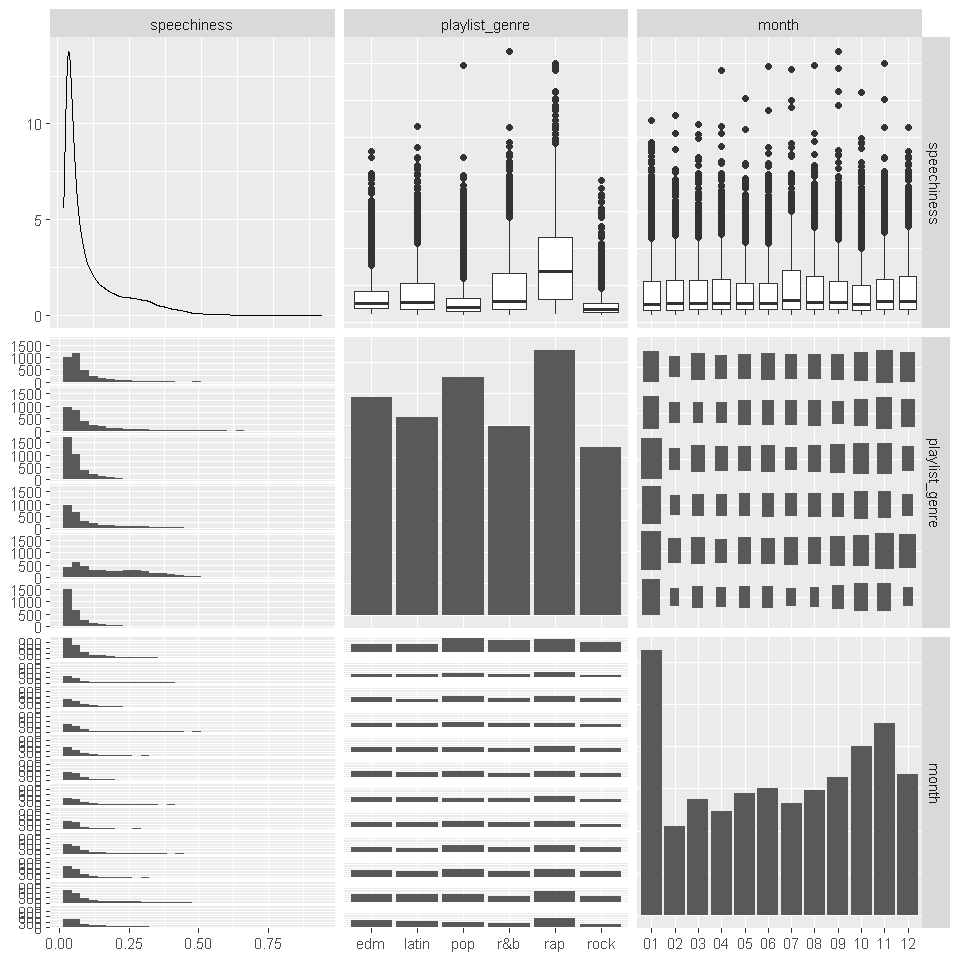

In [32]:
ggpairs(song,columns=c(12, 5, 19), cardinality_threshold = 15, progress = FALSE)

Rap has significantly more speechiness than other genres, which is understandable as it is more focused on speech.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


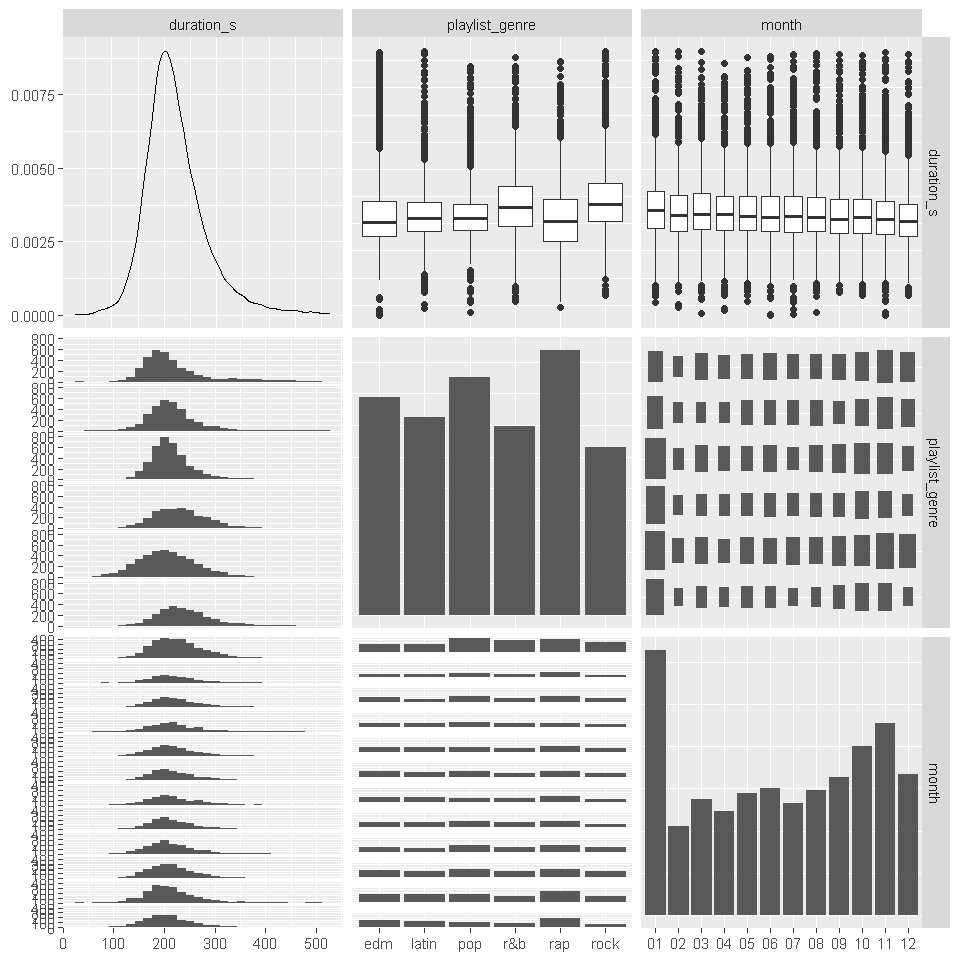

In [33]:
ggpairs(song,columns=c(18, 5, 19), cardinality_threshold = 15, progress = FALSE)

## ACP

In [40]:
suppressWarnings({
res.pca <- PCA(song,quali.sup=c(1,3:6,11,19:21),scale.unit=TRUE,ncp=8)
})

On a décidé de garder la variable key dans l'ACP car même si le nombre de valeurs est fini, elles sont ordonnées. Key représente la tonalité de la musique, augmenter de 1 la key augmente le ton de 0.5 .

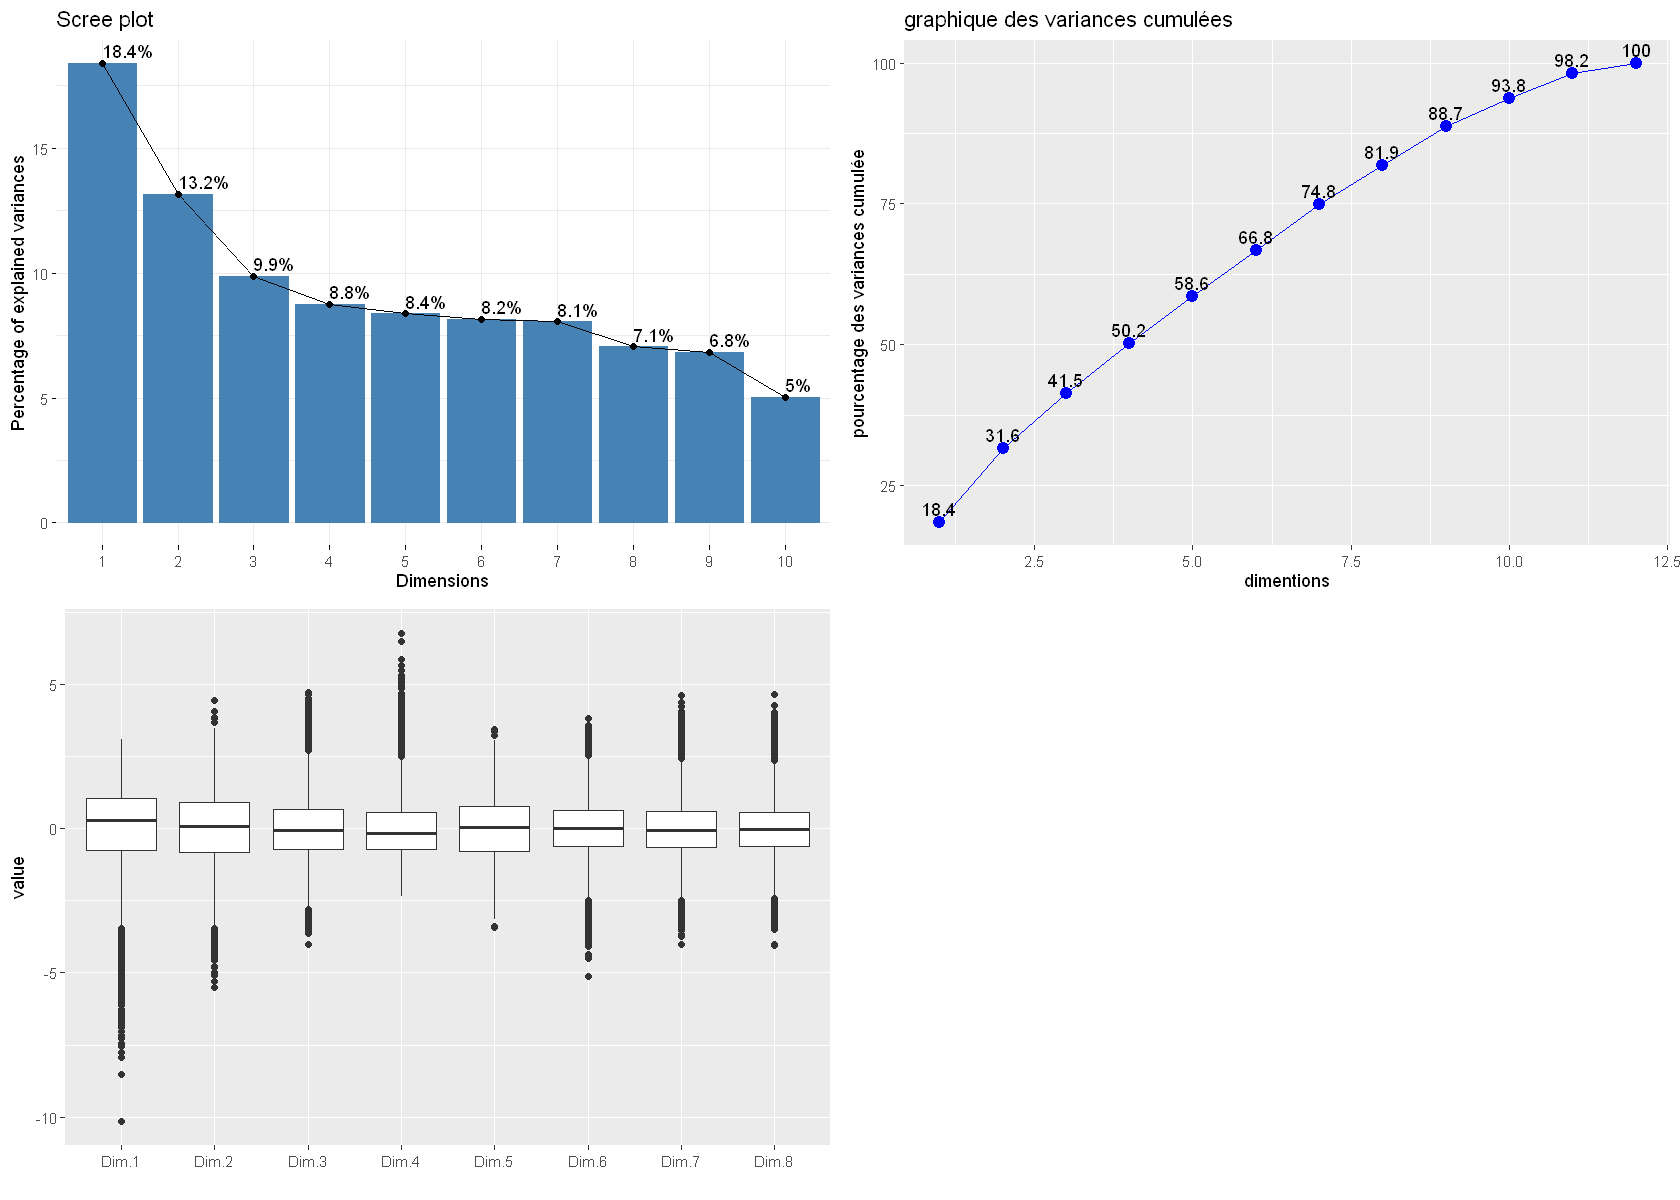

In [41]:
options(repr.plot.width=14,repr.plot.height=10)
#décroissance valeurs propres
g1<-fviz_eig(res.pca,addlabels=TRUE)

#variances cumulées
cum_var <- cumsum(res.pca$eig[,2])

# Graphique avec ggplot2
g2<-ggplot(data.frame(Dimension = 1:length(cum_var), Variance = cum_var), aes(x = Dimension, y = Variance)) +
    geom_point(size = 3, color = "blue") +
    geom_line(color = "blue") +
    labs(title = "graphique des variances cumulées",x='dimentions', y = "pourcentage des variances cumulée") +
    geom_text(aes(y = cum_var, label = round(cum_var, 1)), vjust = -0.5, color = "black") 

g3<-ggplot(melt(res.pca$ind$coord),aes(x=Var2,y=value))+
  geom_boxplot()+
  xlab("")
grid.arrange(g1,g2,g3,ncol=2)

Pour atteindre 80% de la variance, on a besoin de garder 8 composantes. Ce n'est pas très performant, la dimension n'est pas vraiment réduite.

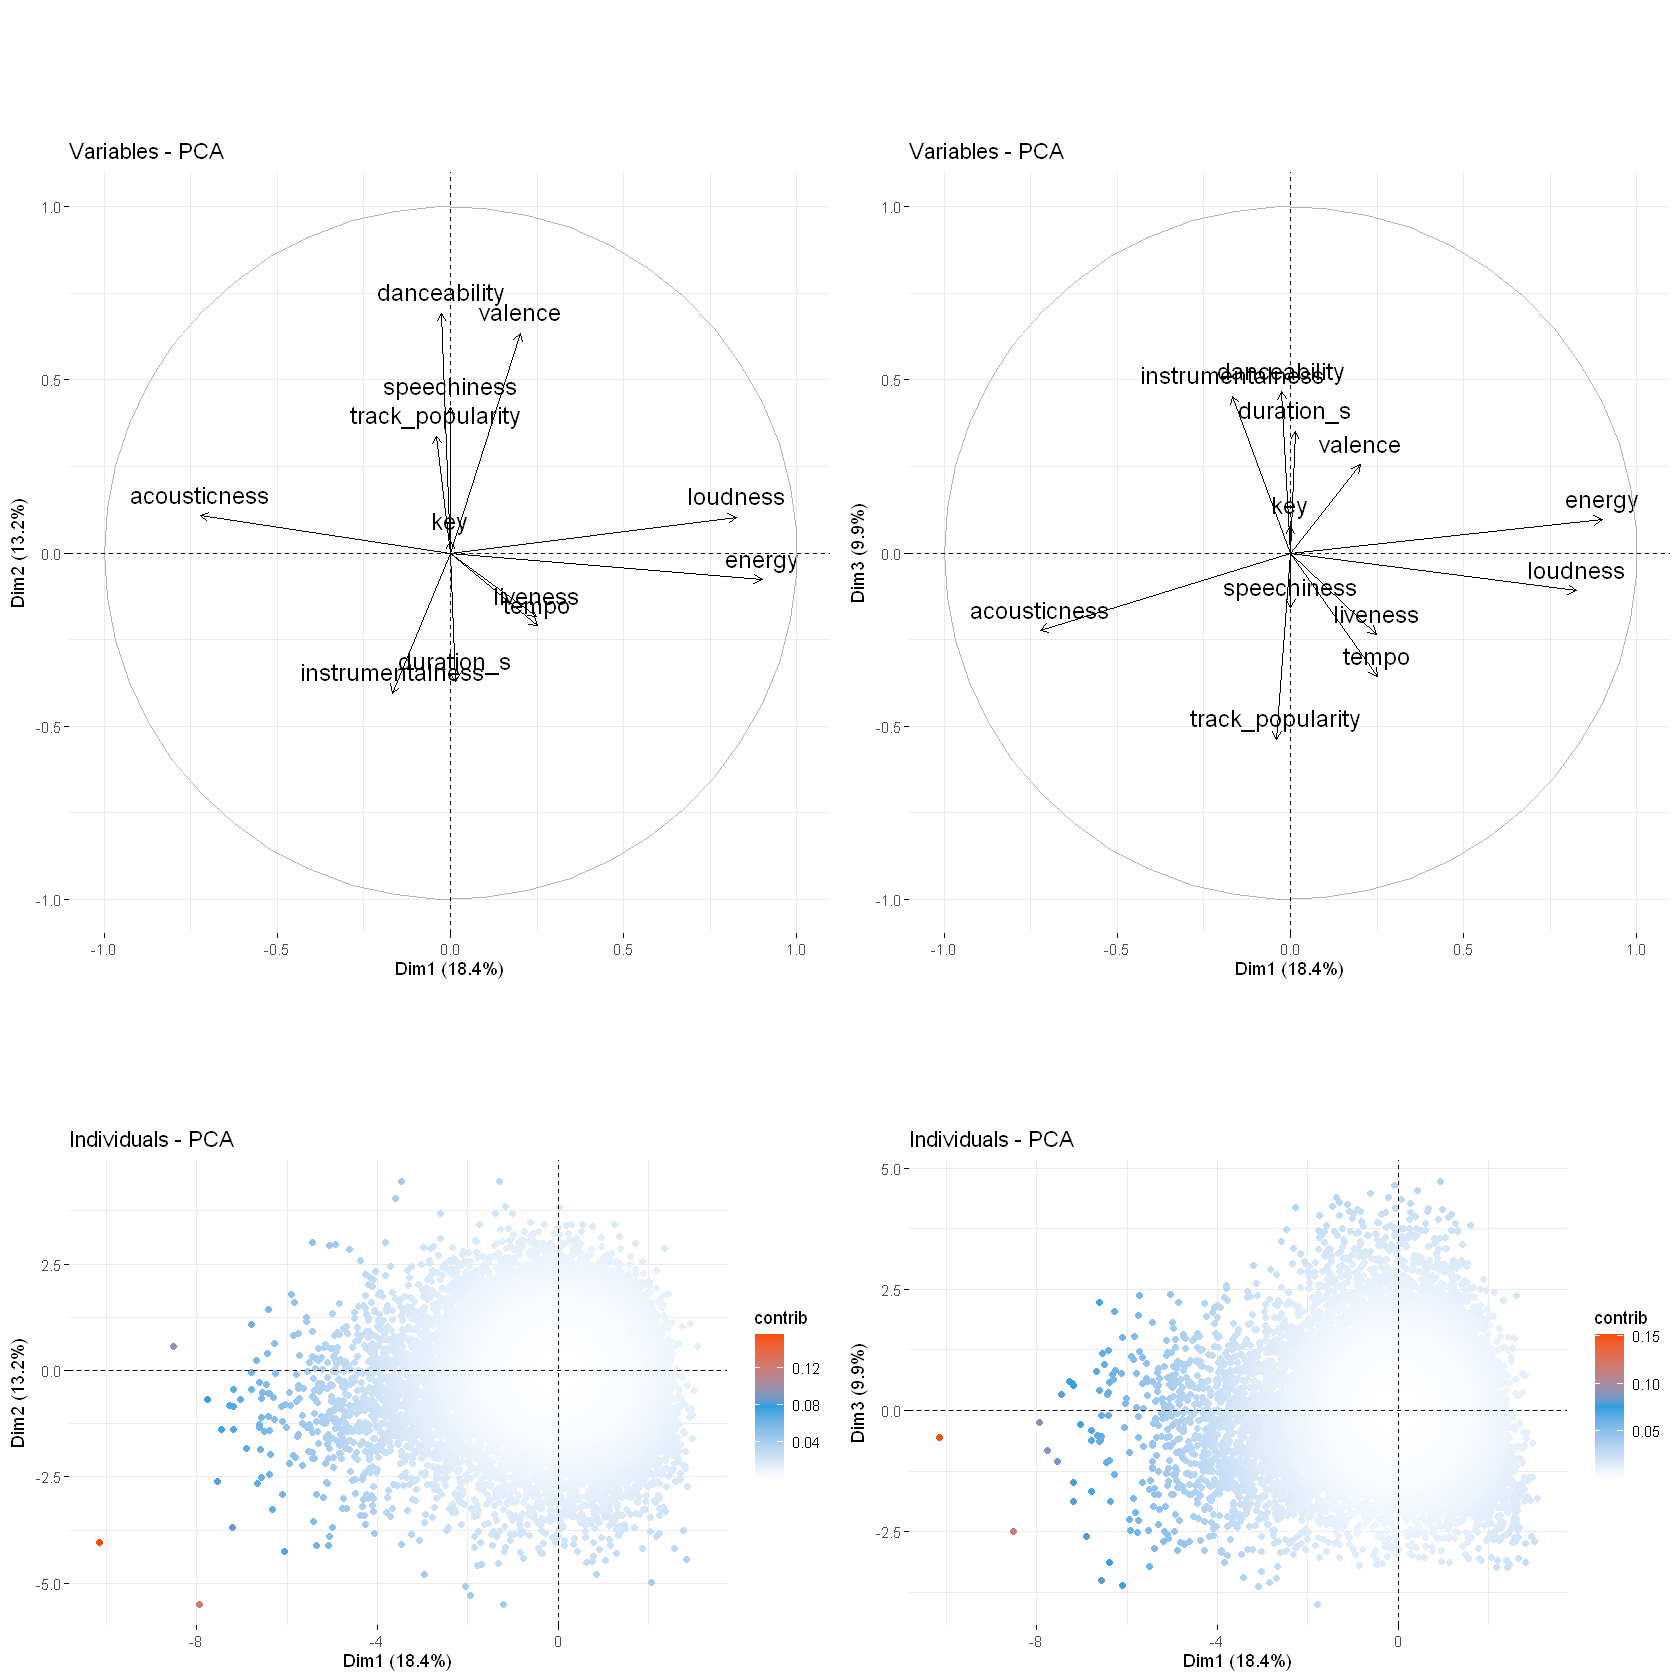

In [42]:
options(repr.plot.width=14,repr.plot.height=14)
g4<-fviz_pca_var(res.pca,labelsize = 5)
g5<-fviz_pca_ind(res.pca, col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ))
g6<-fviz_pca_var(res.pca,axes=c(1,3),labelsize = 5)
g7<-fviz_pca_ind(res.pca,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ),axes=c(1,3))

grid.arrange(g4,g6,g5,g7,ncol=2,nrow=2,heights=c(2,1))

In [43]:
contrib_ind<-res.pca$ind$contrib[,c(1,2)]
top_ind<-order(contrib_ind,decreasing=TRUE)[1:3]
song[top_ind,]

track_artist,track_popularity,track_album_name,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,⋯,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s,month,year,period
<fct>,<int>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<int>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>
The Sleep Specialist,51,Jungle And Forest Sounds,Tropical Nights,latin,tropical,0.2110,0.425000,7,-46.448,⋯,0.0542,0.880,6.13e-01,0.1840,0.0122,116.884,181.204,01,2017,2010s
Nature Sounds,50,"Nature Sounds with Birdsong, Waves, Forest, Garden, And More Beautiful Sounds of the Earth!",Tropical Nights,latin,tropical,0.3180,0.179000,8,-35.427,⋯,0.4790,0.877,3.82e-05,0.2260,0.4220,97.368,45.000,04,2015,2010s
Natural Sound Makers,52,Forest By Night,Tropical Nights,latin,tropical,0.0787,0.000175,7,-35.960,⋯,0.0580,0.118,9.72e-01,0.0793,0.0116,169.062,264.154,01,2017,2010s


Les 3 individus qui contribuent plus que les autres dans les deux premiers plans factoriels ne sont peut-être pas des outliers mais des musiques qui sont très bien expliquées par ses plans factoriels car ce sont des musiques très spécifiques/particulières.

La première dimension sépare les musiques plutôt dynamique/énergique et les musiques plus fluides/calmes.
La seconde dimension sépare les musiques populaires/dansantes/courtes et la musique plus classique/instrumentale/longue.
La troisième dimension sépare les musiques populaires et les musiques dansantes type bal.
La quatrième dimension représente les musiques enregistrées en concert.
La cinquième dimension représente la clé de la musique.
Les 3 dernières dimensions sont difficilement interprétables.

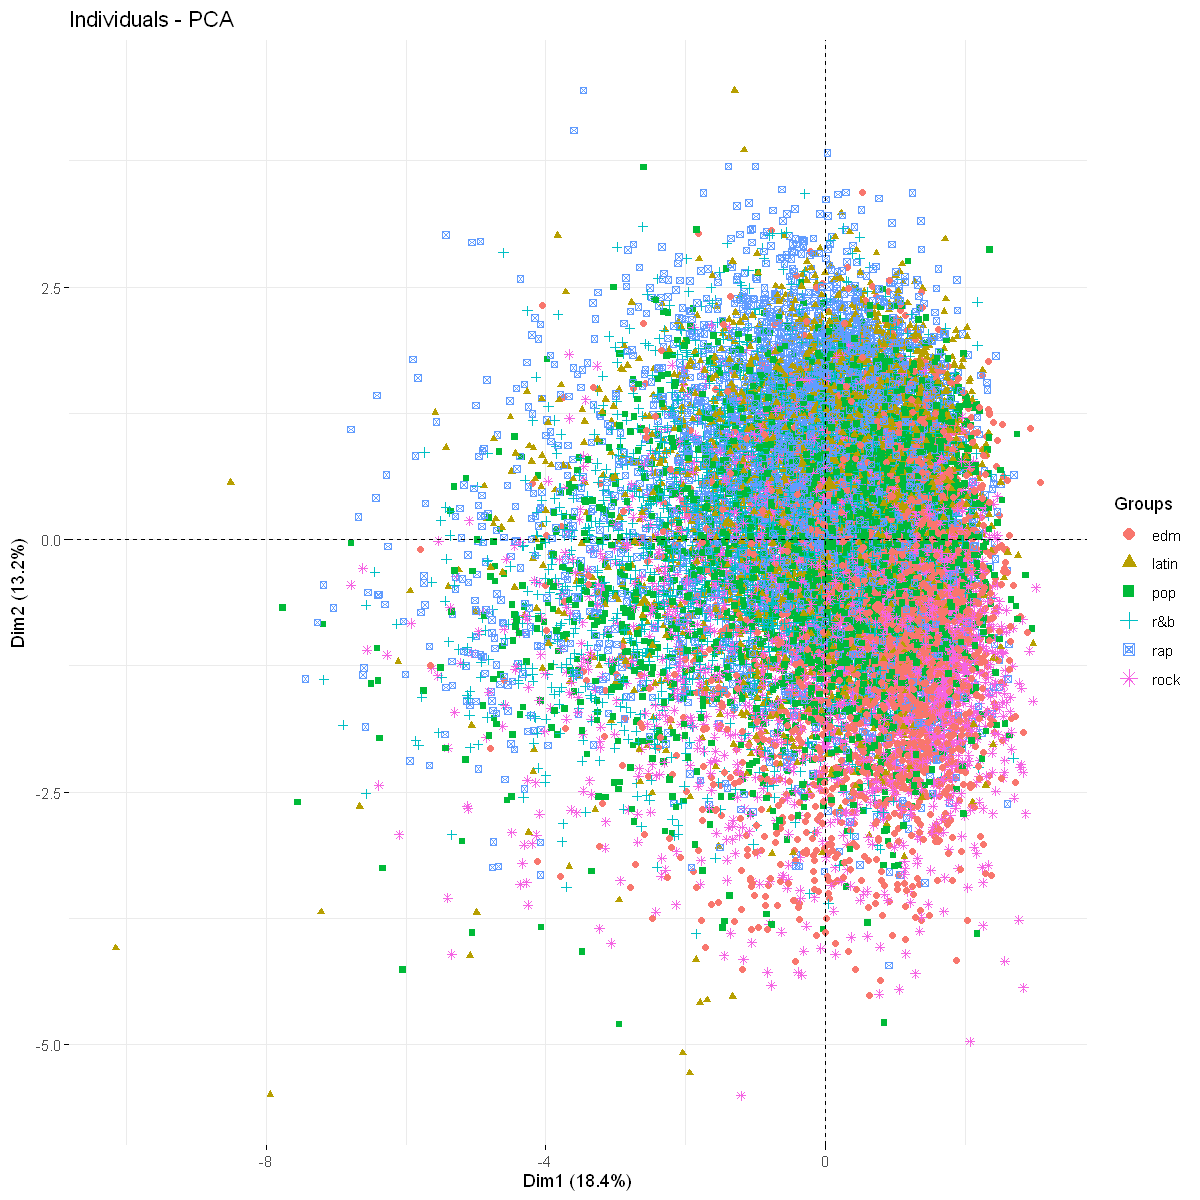

In [44]:
options(repr.plot.width=10,repr.plot.height=10)
g8<-fviz_pca_ind(res.pca, habillage=song$playlist_genre,label="none")
g8

On voit qu'on ne peut pas discriminer le genre de musique avec uniquement le premier plan factoriel.

## LDA,QDA,KNN pour prédire le genre

## LDA

On va faire une LDA pour essayer de prédire le genre de la playlist dans laquelle se trouve la musique.

Pour facilliter la LDA, on va transformer les variables qualitatives en one-hot. On ne va pas garder que les propriétés physiques de la musique + la popularité. On va supprimer aussi le sous genre car si on ne connait pas le genre on ne connait pas le sous genre.
On va scale les données quantitatives comme pour l'ACP afin que les variables tempo et duration_s ne prennent pas trop d'importance par rapport aux autres variables qui ne prennent pas les mêmes échelles de valeurs.

In [49]:
songLDA<-subset(song, select=-track_artist)
songLDA<-subset(songLDA, select=-track_album_name)
songLDA<-subset(songLDA, select=-playlist_name)
songLDA<-subset(songLDA, select=-playlist_subgenre)
songLDA<-subset(songLDA, select=-month)
songLDA<-subset(songLDA, select=-year)
songLDA<-subset(songLDA, select=-period)
#songLDA<-subset(songLDA, select=-pop)

In [50]:
songLDA[,c(1,3:4,6,8:14)]<-scale(songLDA[,c(1,3:4,6,8:14)])
head(songLDA)

track_popularity,playlist_genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s
<dbl>,<fct>,<dbl>,<dbl>,<int>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
-1.2475432,rap,1.7573315,-1.5381326,10,0.0257840,0,0.2820806,-0.6990892,-0.3873568,-0.4771834,-1.7593252,0.6963539,-1.18732183
-0.4740539,pop,-0.9814686,-0.6070465,9,-2.1465657,0,-0.7806688,-0.8160422,3.2219149,-0.5162025,-1.1563614,0.5446274,0.26562517
0.2027493,rap,-0.7337380,0.8112358,8,0.6042184,1,1.6546001,-0.7392409,-0.3811107,0.4462690,0.2416912,-1.1807785,0.99333001
-0.8607986,r&b,0.9522069,1.5041371,3,1.1846348,1,-0.5423842,0.8642074,-0.3942486,0.8364601,0.2717107,-0.4806948,-0.50201500
0.2994355,latin,0.9728511,0.7787560,0,1.0752905,0,-0.5204620,-0.3185212,-0.3949112,-0.3601260,1.3352599,-0.8861575,0.07902736
-0.1356523,latin,1.1035978,-0.3905149,9,0.6868046,1,-0.7454027,0.9907725,-0.3937591,0.6088486,0.8163508,-0.4084196,-0.29455098


In [51]:
#install.packages('MASS')
#install.packages("effectsize")

In [52]:
set.seed(42)
sample<-sample(c(TRUE,FALSE),nrow(songLDA),replace=TRUE,prob=c(0.7,0.3))
songLDA<-standardize(songLDA,exclude=c("playlist_genre","mode"))
train<-songLDA[sample,]
test<-songLDA[!sample,]


res.lda<-lda(playlist_genre~.,data=train)

In [53]:
lda_pred<-predict(res.lda,test)

In [54]:
library(caret)
conf_matrix <- confusionMatrix(lda_pred$class, factor(test$playlist_genre))
print(conf_matrix)

Le chargement a nécessité le package : lattice



Confusion Matrix and Statistics

          Reference
Prediction edm latin pop r&b rap rock
     edm   556   100 141  34 114   75
     latin  89   331 155 110 140   40
     pop   215   199 446 137 131  115
     r&b    37    87 106 301  96   85
     rap    91   166 120 185 728   13
     rock   59    63 173  88  52  450

Overall Statistics
                                          
               Accuracy : 0.4665          
                 95% CI : (0.4538, 0.4792)
    No Information Rate : 0.2092          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.3558          
                                          
 Mcnemar's Test P-Value : 2.371e-15       

Statistics by Class:

                     Class: edm Class: latin Class: pop Class: r&b Class: rap
Sensitivity             0.53104      0.34989    0.39089    0.35205     0.5773
Specificity             0.90685      0.89492    0.83691    0.92055     0.8794
Pos Pred Value   

On obtient une précision de 47% sur la classification ce qui n'est pas très bon.

Essayer QDA, LDA sur espace d'ACP

## LDA sur Espace d'ACP

In [55]:
trainACP<-res.pca$ind$coord[sample,]
trainACP = as.data.frame(trainACP)
trainACP$playlist_genre = train$playlist_genre
testACP<-res.pca$ind$coord[!sample,]
testACP = as.data.frame(testACP)
res.lda<-lda(playlist_genre~.,data=trainACP)

In [56]:
lda_pred<-predict(res.lda,testACP)

In [57]:
conf_matrix <- confusionMatrix(lda_pred$class, factor(test$playlist_genre))
print(conf_matrix)

Confusion Matrix and Statistics

          Reference
Prediction edm latin pop r&b rap rock
     edm   540   114 154  38 100  136
     latin  78   297 159 128 134   55
     pop   213   213 430 125 151  153
     r&b    28    90 110 282 112  113
     rap   104   175 140 209 714   17
     rock   84    57 148  73  50  304

Overall Statistics
                                          
               Accuracy : 0.4258          
                 95% CI : (0.4133, 0.4384)
    No Information Rate : 0.2092          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.3053          
                                          
 Mcnemar's Test P-Value : 1.083e-15       

Statistics by Class:

                     Class: edm Class: latin Class: pop Class: r&b Class: rap
Sensitivity             0.51576      0.31395    0.37686    0.32982     0.5662
Specificity             0.89119      0.89099    0.82505    0.91243     0.8647
Pos Pred Value   

Pas fou

## QDA

In [58]:
res.qda<-qda(playlist_genre~.,data=train)

In [59]:
qda_pred<-predict(res.qda,test)

In [60]:
conf_matrix <- confusionMatrix(qda_pred$class, factor(test$playlist_genre))
print(conf_matrix)

Confusion Matrix and Statistics

          Reference
Prediction edm latin pop r&b rap rock
     edm   636    92 149  29  76   61
     latin  44   231  73  80 132   23
     pop   216   319 544 169 182  124
     r&b    27   106 122 345 162   75
     rap    65   119  86 137 654   26
     rock   59    79 167  95  55  469

Overall Statistics
                                          
               Accuracy : 0.4776          
                 95% CI : (0.4649, 0.4903)
    No Information Rate : 0.2092          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.3697          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       

Statistics by Class:

                     Class: edm Class: latin Class: pop Class: r&b Class: rap
Sensitivity              0.6074      0.24419    0.47677    0.40351     0.5186
Specificity              0.9183      0.93074    0.79333    0.90489     0.9092
Pos Pred Value   

> On remarque que l'on atteint environ 50% de précision, ce qui est visiblement meilleur que la LDA/LDA dans l'espace d'ACP. Cependant, il serait souhaitable d'avoir de meilleurs résultats.

## kNN

In [61]:
knn_genre<-train(playlist_genre~.,data=train,method="knn",trControl=trainControl(method="cv"),tuneGrid=data.frame(k=seq(10,30)))

In [62]:
knn_genre

k-Nearest Neighbors 

14094 samples
   13 predictor
    6 classes: 'edm', 'latin', 'pop', 'r&b', 'rap', 'rock' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 12686, 12683, 12684, 12685, 12686, 12685, ... 
Resampling results across tuning parameters:

  k   Accuracy   Kappa    
  10  0.4754549  0.3668081
  11  0.4792866  0.3713312
  12  0.4805655  0.3726862
  13  0.4853192  0.3783624
  14  0.4869512  0.3802215
  15  0.4875913  0.3809307
  16  0.4886557  0.3821406
  17  0.4901448  0.3839391
  18  0.4948263  0.3895140
  19  0.4945440  0.3891831
  20  0.4961753  0.3910959
  21  0.4978794  0.3930996
  22  0.4948296  0.3894195
  23  0.4946867  0.3892546
  24  0.4961749  0.3910095
  25  0.4933383  0.3875488
  26  0.4959638  0.3907260
  27  0.4961752  0.3909007
  28  0.4977358  0.3928413
  29  0.4970265  0.3918666
  30  0.4975925  0.3925082

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was k = 21.

In [63]:
best_knn<-knn3(playlist_genre~.,data=train,k=knn_genre$bestTune$k)
pred_genre<-predict(best_knn,test,type="class")
conf_matrix <- confusionMatrix(pred_genre, factor(test$playlist_genre))
print(conf_matrix)

Confusion Matrix and Statistics

          Reference
Prediction edm latin pop r&b rap rock
     edm   692    94 191  37  91   77
     latin  52   359 124 103 124   38
     pop   178   214 493 166 130  150
     r&b    24    91 117 298 102   84
     rap    61   148  99 191 774   26
     rock   40    40 117  60  40  403

Overall Statistics
                                          
               Accuracy : 0.5008          
                 95% CI : (0.4881, 0.5135)
    No Information Rate : 0.2092          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.396           
                                          
 Mcnemar's Test P-Value : < 2.2e-16       

Statistics by Class:

                     Class: edm Class: latin Class: pop Class: r&b Class: rap
Sensitivity              0.6609      0.37949    0.43208    0.34854     0.6138
Specificity              0.9016      0.91322    0.82852    0.91920     0.8899
Pos Pred Value   

A nouveau environ 51% de précision ce qui n'est toujours pas satisfaisant.

## CA

#### Nous transformons la variable quantitative `track_popularity` en variable qualitative, afin de l'utiliser dans une CA sur elle et la variable `playlist_genre `. Pour vérifier l'indépendance,on utilise un test du $\chi^2$.

In [64]:
song$track_popularity_quali <- as.factor(floor((song$track_popularity)/10))

In [65]:
table_genre_popu<-table(song$playlist_genre,song$track_popularity_quali)

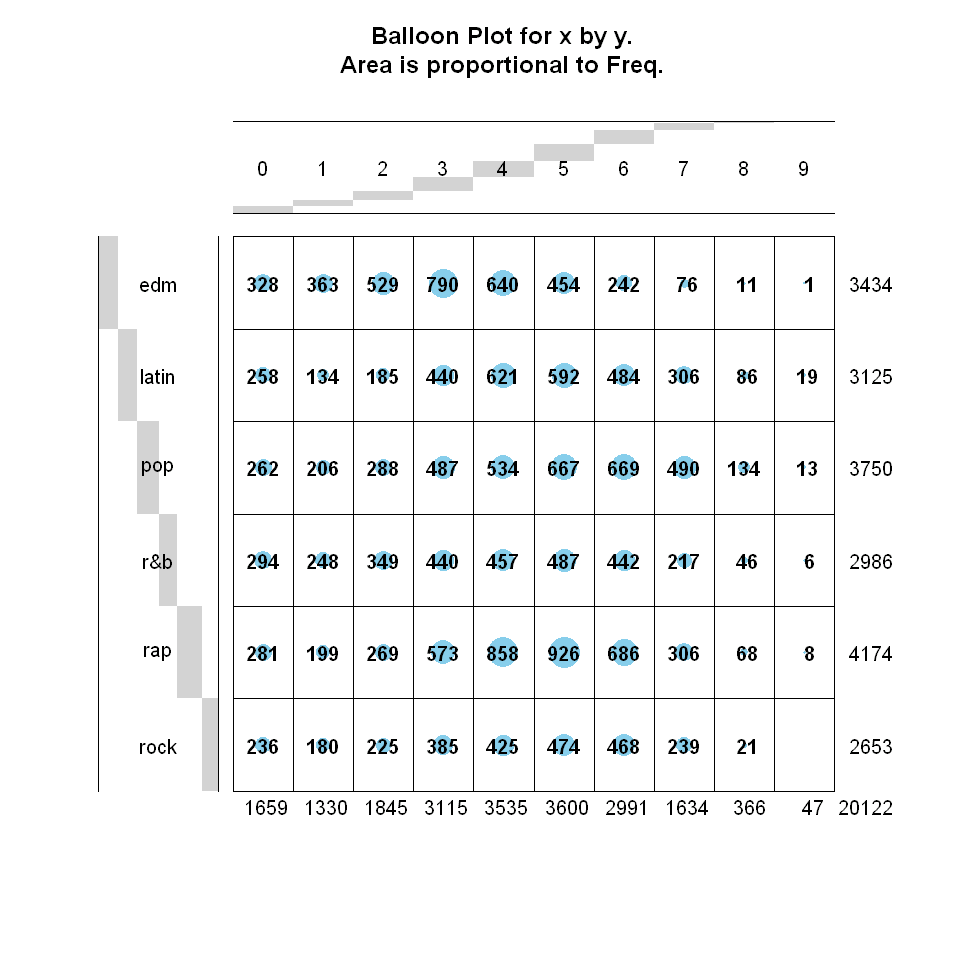

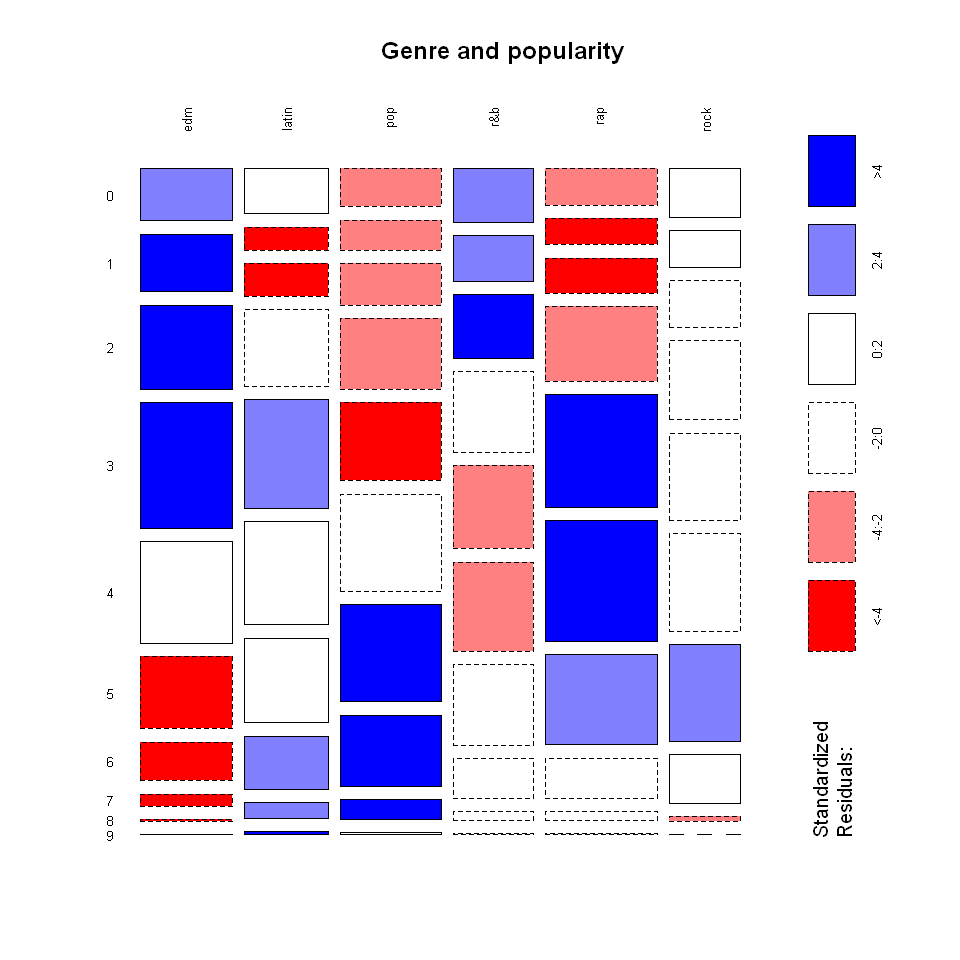

In [67]:
options(repr.plot.width=8,repr.plot.height=8)
balloonplot(t(table_genre_popu))
mosaicplot(table_genre_popu, shade = TRUE, las=2, main = "Genre and popularity")

> On observe qu'il y a très peu de sons populaires et les dépendances entres facteurs ne sont pas flagrantes. Nous allons mainteneant réalisé un test du $\chi^2$ pour voir si il y a indépendance et si la CA est utile ou non.

In [68]:
chisq.test(table_genre_popu)


	Pearson's Chi-squared test

data:  table_genre_popu
X-squared = 1383.8, df = 45, p-value < 2.2e-16


> La p-valeur est inférieur au niveau de confiance 5%, on rejette donc l'hypothèse d'indépendance à se niveau de confiance. On va donc pouvoir faire une CA pour trouver ces dépendances.

In [69]:
res.ca = CA(table_genre_popu, graph=FALSE)

In [70]:
res.ca$eig

,eigenvalue,percentage of variance,cumulative percentage of variance
dim 1,0.0531783592,77.3271325,77.32713
dim 2,0.0097015916,14.1071720,91.43430
dim 3,0.0041395968,6.0194251,97.45373
dim 4,0.0010785165,1.5682806,99.02201
dim 5,0.0006725698,0.9779898,100.00000


> On voit qu'avec 2 dimensions on conserve plus de 90% de la variance ce qui est très satisfaisant. On va maintenant plot les facteurs dans le premier plan de CA.

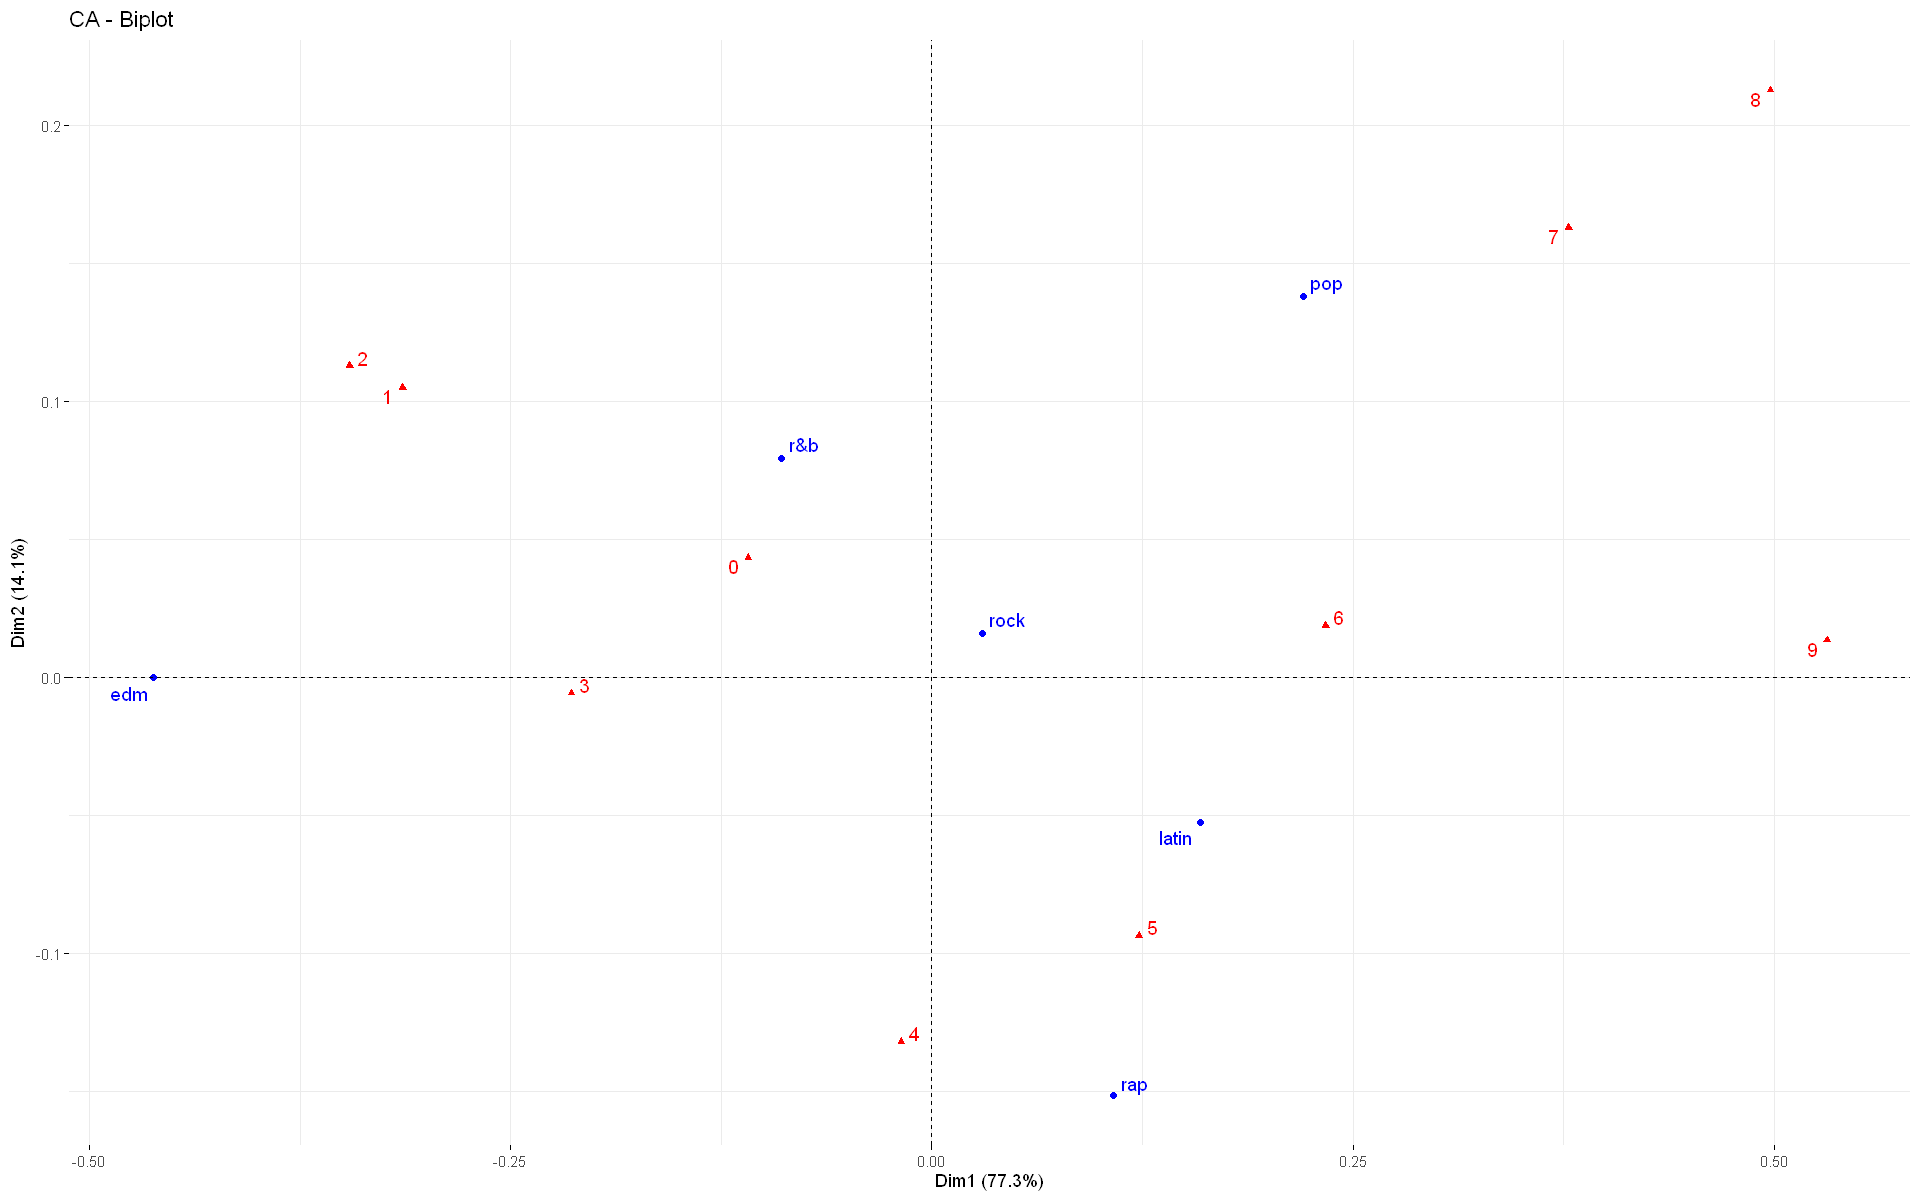

In [71]:
options(repr.plot.width=16,repr.plot.height=10)
fviz_ca_biplot(res.ca, repel=TRUE)

> On observe un lien entre les genre `edm`, `r&b` et les faibles popularités. On observe également un lien entre `rock`,`rap`,`latin` et les popularités moyennes. De mêmen `pop` a un lien avec les hautes popularité.
> On interprète cela comme le fait que le genre `pop` est un genre assez général, que tout le monde peut écouter assez souvent et aimer. Au contraire, les genres `edm` et `r&b` sont plus niches et ont une communauté plutôt restreinte. Les 3 derniers sont des genres avec des communautés plus importantes mais on ne peut pas forcément écouter ces musiques avec tout le monde et/ou dans toutes les situations.

## MCA

Pour étudier un impact potentiel du tempo dans certains intervalles, on va créer une variable `tempo_quali` de la même manière que la popularité dans la CA.

In [72]:
song <- song %>%
  mutate(
    tempo_quali = case_when(
      tempo < 40   ~ "Larghissimo",
      tempo < 60   ~ "Largo",
      tempo < 80   ~ "Adagio",
      tempo < 100  ~ "Andante",
      tempo < 120  ~ "Allegretto",
      tempo < 140  ~ "Vivace",
      tempo < 188  ~ "Presto",
      TRUE         ~ "Prestissimo"
    ),
    tempo_quali = as.factor(tempo_quali)
  )


In [80]:
song_quali<- song[c(5,21,22,23)]

In [81]:
head(song_quali)

playlist_genre,period,track_popularity_quali,tempo_quali
<fct>,<fct>,<fct>,<fct>
rap,2010s,1,Presto
pop,1980s,3,Vivace
rap,1990s,4,Andante
r&b,2010s,2,Allegretto
latin,2010s,5,Andante
latin,2010s,4,Allegretto


In [82]:
res.mca = MCA(song_quali, graph=FALSE)


In [83]:
summary(res.mca)


Call:
MCA(X = song_quali, graph = FALSE) 


Eigenvalues
                       Dim.1   Dim.2   Dim.3   Dim.4   Dim.5   Dim.6   Dim.7
Variance               0.410   0.365   0.312   0.298   0.276   0.265   0.260
% of var.              6.070   5.412   4.615   4.414   4.093   3.920   3.859
Cumulative % of var.   6.070  11.482  16.097  20.511  24.604  28.524  32.383
                       Dim.8   Dim.9  Dim.10  Dim.11  Dim.12  Dim.13  Dim.14
Variance               0.257   0.256   0.253   0.252   0.251   0.250   0.250
% of var.              3.814   3.788   3.755   3.739   3.723   3.703   3.697
Cumulative % of var.  36.197  39.984  43.739  47.478  51.201  54.904  58.601
                      Dim.15  Dim.16  Dim.17  Dim.18  Dim.19  Dim.20  Dim.21
Variance               0.249   0.248   0.247   0.244   0.240   0.238   0.233
% of var.              3.687   3.673   3.656   3.610   3.561   3.530   3.457
Cumulative % of var.  62.288  65.962  69.618  73.228  76.789  80.319  83.776
                   

In [86]:
round(res.mca$var$cos2 * 100, 2)

,Dim 1,Dim 2,Dim 3,Dim 4,Dim 5
edm,51.82,11.16,4.73,0.05,0.61
latin,0.11,8.57,6.48,0.61,32.58
pop,1.03,1.25,34.52,1.56,10.32
r&b,3.95,2.32,11.40,28.03,5.31
rap,1.76,13.54,8.82,29.70,1.91
rock,26.33,45.13,0.00,1.12,0.64
1950s,0.07,0.01,0.01,0.15,0.28
1960s,3.10,6.09,0.05,0.22,0.12
1970s,9.21,25.71,1.13,3.92,1.16
1980s,6.23,11.17,0.23,2.33,3.81


- **Dimension 1** : Genres edm et rock, années 2010, tempo vivace (120-140)
- **Dimension 2** : Rock des années 70
- **Dimension 3** : Pop des années 90 avec un tempo allegretto (100-120)
- **Dimension 4** : Rap et R&B tempo presto (140-188)
- **Dimension 5** : Latin des années 2000 à très faible popularité, tempo adagio (60-80)

Idée, mettre les différents clustering obtenus dans la MCA

## Retrouver la décennie d'un titre en fonction de ses caractéristiques physiques : possible?

In [48]:
head(song)

,track_artist,track_popularity,track_album_name,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,⋯,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s,month,year,period
,<fct>,<int>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<int>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>
1,Ed Sheeran,66,I Don't Care (with Justin Bieber) [Loud Luxury Remix],Pop Remix,pop,dance pop,0.748,0.916,6,-2.634,⋯,0.0583,0.1020,0.00e+00,0.0653,0.518,122.036,194.754,06,2019,2010s
2,Maroon 5,67,Memories (Dillon Francis Remix),Pop Remix,pop,dance pop,0.726,0.815,11,-4.969,⋯,0.0373,0.0724,4.21e-03,0.3570,0.693,99.972,162.600,12,2019,2010s
3,Zara Larsson,70,All the Time (Don Diablo Remix),Pop Remix,pop,dance pop,0.675,0.931,1,-3.432,⋯,0.0742,0.0794,2.33e-05,0.1100,0.613,124.008,176.616,07,2019,2010s
4,The Chainsmokers,60,Call You Mine - The Remixes,Pop Remix,pop,dance pop,0.718,0.930,7,-3.778,⋯,0.1020,0.0287,9.43e-06,0.2040,0.277,121.956,169.093,07,2019,2010s
5,Lewis Capaldi,69,Someone You Loved (Future Humans Remix),Pop Remix,pop,dance pop,0.650,0.833,1,-4.672,⋯,0.0359,0.0803,0.00e+00,0.0833,0.725,123.976,189.052,03,2019,2010s
6,Ed Sheeran,67,Beautiful People (feat. Khalid) [Jack Wins Remix],Pop Remix,pop,dance pop,0.675,0.919,8,-5.385,⋯,0.1270,0.0799,0.00e+00,0.1430,0.585,124.982,163.049,07,2019,2010s


In [122]:
song_dec<-song[c(7:18,21)]
head(song_dec)

danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s,period
<dbl>,<dbl>,<int>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
0.914,0.408,10,-6.712,0,0.1410,2.68e-02,0.001790,0.116,0.0944,140.026,150.909,2010s
0.516,0.580,9,-13.288,0,0.0295,2.43e-06,0.857000,0.110,0.2350,135.903,238.227,1980s
0.552,0.842,8,-4.961,1,0.2850,1.76e-02,0.003270,0.258,0.5610,89.017,281.960,1990s
0.797,0.970,3,-3.204,1,0.0545,3.85e-01,0.000157,0.318,0.5680,108.041,192.094,2010s
0.800,0.836,0,-3.535,0,0.0568,1.14e-01,0.000000,0.134,0.8160,97.023,227.013,2010s
0.819,0.620,9,-4.711,1,0.0332,4.14e-01,0.000273,0.283,0.6950,110.005,204.562,2010s


In [124]:
groupes <-list(
    physique = c("danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence"),
    musique = c("key", "mode"),
    tempo = c("tempo"),
    durée = c("duration_s"),
    période = c("period"))
ordre_col <- unlist(groupes)
song_dec_ord <- song_dec[, ordre_col]
res.mfa_dec <- MFA(song_dec_ord, group = c( 8, 2, 1, 1, 1), ncp=10,type = c("s", "n", "s", "s", "n"), name.group = c("physique", "musique", "tempo", "durée", "période"),graph=FALSE)

ERROR: Error in MFA(song_dec_ord, group = c(8, 2, 1, 1, 1), ncp = 10, type = c("s", : factors are not defined in the qualitative groups


## Comprendre le lien entre popularité et composantes de la musique

In [ ]:
res.lm<-lm(track_popularity~.,data=song)

In [ ]:
summary(res.lm)

### Avec NMF

In [95]:
song_nmf<-subset(songLDA, select=-c(mode,playlist_genre,track_popularity))

In [96]:
song_nmf_scaled <-as.data.frame(lapply(song_nmf,rescale))
song_nmf_matrix<-as.matrix(song_nmf_scaled)

In [97]:
n_components=5
nmf_result<-nmf(song_nmf_matrix,rank=n_components,seed=42)
W<-basis(nmf_result)
H<-coef(nmf_result)

In [98]:
H

danceability,energy,key,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s
0.08054094,9.110368e-02,2.220446e-16,0.08898327,6.209157e-12,3.558344e-08,3.407385e-01,1.541751e-02,0.0003171146,0.05449779,0.05843683
0.12936097,1.508636e-01,1.183263e+00,0.20653050,3.329599e-06,4.575997e-05,2.220446e-16,1.245637e-03,0.0546764865,0.08425392,0.10514241
0.31731307,5.189189e-01,2.220446e-16,0.56083374,1.605951e-01,2.100260e-06,2.220446e-16,3.035641e-01,0.0138083232,0.32759119,0.26227999
0.44617483,4.423125e-01,2.220446e-16,0.46723799,3.018751e-04,4.457440e-05,2.220446e-16,1.678081e-07,0.5906926603,0.21334996,0.21124173
0.15504473,3.346815e-08,2.220446e-16,0.17871087,3.178460e-02,4.433311e-01,2.220446e-16,3.890594e-02,0.0929752389,0.08795841,0.08587837


- **Composante 1** : musique instrumentale
- **Composante 2** : clé du morceau (plus ou moins aigu/grave)
- **Composante 3** : les musiques forte ,qui pulsent, qui t'attaque (pas calme), musique de concert
- **Composante 4**: les musiques de la boom (entrainante,ce qui donne envie de faire la fête et de bouger) 
- **Composante 5** : musique acoustique (vrai instrument, pas électronique)

In [99]:
W_df<-as.data.frame(W)
colnames(W_df)<-paste0("factor_",1:ncol(W_df))
W_df$popularity<-song$track_popularity
correlations<-cor(W_df)
print(correlations["popularity",])

     factor_1      factor_2      factor_3      factor_4      factor_5 
-0.1539031205  0.0005277881 -0.0378204384  0.0463653697  0.0754102510 
   popularity 
 1.0000000000 


On observe une très légère corrélation négative entre la popularité et la 1ère composante latente qui correspond uniquement à l'instrumentalité. Ce résultat ne nous apporte pas beaucoup d'informations car avec la matrice de corrélations de base, on possédait déjà cette valeur de corrélation.

Si on veut faire une chanson qui a du succès, nos résultats suggèrent de faire une musique entraînante, avec beaucoup de parties vocales, assez calme (pas agressive), avec de vrais instruments; Néanmoins, les corrélations sont très faibles, il n'y a donc pas de recette magique pour produire une chanson à succès et on peut supposer que la popularité d'une chanson dépend davantage de l'artiste qui la sort que de ses propriétés physiques...

## MFA puis regression linéaire pour popularité

In [100]:
song_mfa<-subset(song, select=-c(track_popularity, track_album_name, playlist_name, month, year))
song_mfa$key<-as.factor(song_mfa$key)

On choisit les groupes de façon suivante, sachant qu'ils doivent être homogènes:
- artiste
- genre et sous-genre
- caractéristiques physiques calculées par Spotify (danceability, speechiness, ...) dont les méthodes de calcul ne sont pas connues
- caractéristiques musicales (variables key et mode)
- tempo
- durée
- période

In [112]:
groupes <-list(
    genre = c("playlist_genre", "playlist_subgenre"),
    physique = c("danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence"),
    musique = c("key", "mode"),
    tempo = c("tempo"),
    durée = c("duration_s"),
    période = c("period"))
ordre_col <- unlist(groupes)
song_mfa_ord <- song_mfa[, ordre_col]
res.mfa <- MFA(song_mfa_ord, group = c( 2, 8, 2, 1, 1, 1), ncp=7,type = c("n", "s", "n", "s", "s", "n"), name.group = c("genre", "physique", "musique", "tempo", "durée", "période"),graph=FALSE)

In [113]:
data_mfa<-as.data.frame(res.mfa$ind$coord)
data_mfa$popularity<-song$track_popularity

In [114]:
head(data_mfa)

,Dim.1,Dim.2,Dim.3,Dim.4,Dim.5,Dim.6,Dim.7,popularity
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,-1.5474066,-0.9871174,-0.3223054,1.9376634,-0.2637169,-0.03984913,-0.4813541,18
2,2.0873957,0.4387897,-0.7620305,-1.5681259,-1.4208235,-3.46880906,0.5241822,34
3,0.7129939,-1.7346106,1.8934016,2.1156437,-0.7465435,-0.80246020,0.3617264,48
4,-0.5696174,-0.5302267,-0.3988402,-1.0139341,-0.1325466,0.82627022,-0.5104079,26
5,-0.6690774,-0.1552728,0.3424664,-0.9931562,1.4935652,0.49412609,1.8592979,50
6,-0.5163101,-0.3728040,-0.7636815,-0.7901993,1.3233730,0.39308773,1.9098103,41


In [115]:
sample<-sample(c(TRUE,FALSE),nrow(data_mfa),replace=TRUE,prob=c(0.7,0.3))
train<-data_mfa[sample,]
test<-data_mfa[!sample,]

In [116]:
lm.mfa<-lm(popularity~.,data=train)

In [117]:
summary(lm.mfa)


Call:
lm(formula = popularity ~ ., data = train)

Residuals:
    Min      1Q  Median      3Q     Max 
-54.229 -12.757   1.609  15.230  52.638 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  43.6784     0.1699 257.110  < 2e-16 ***
Dim.1        -0.5718     0.1253  -4.565 5.04e-06 ***
Dim.2        -1.0589     0.1369  -7.737 1.08e-14 ***
Dim.3        -2.4977     0.1492 -16.738  < 2e-16 ***
Dim.4         0.7979     0.1577   5.059 4.26e-07 ***
Dim.5         2.6766     0.1564  17.116  < 2e-16 ***
Dim.6        -1.8620     0.1678 -11.097  < 2e-16 ***
Dim.7        -0.6144     0.1664  -3.692 0.000223 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 20.13 on 14038 degrees of freedom
Multiple R-squared:  0.05492,	Adjusted R-squared:  0.05445 
F-statistic: 116.5 on 7 and 14038 DF,  p-value: < 2.2e-16


In [118]:
pred.pop<-predict(lm.mfa,test)

In [119]:
sum(abs(pred.pop-test$popularity))/length(pred.pop)

[1] 16.3263

In [120]:
lm.mfa_intonly<-lm(popularity~1,data=train)
pred.pop_intonly<-predict(lm.mfa_intonly,test)
sum(abs(pred.pop_intonly-test$popularity))/length(pred.pop_intonly)

[1] 16.95311

Pas très efficace, on a une MAE à peine plus faible que pour le modèle intercept only qui estime par la popularité moyenne.